# EIT Transcription Pipeline
## Automatic Speech Recognition for Elicited Imitation Task Responses

This notebook transcribes the segmented response WAV files produced by the **v3 segmentation pipeline**.

### Backend Selection (macOS)

| Backend | Best for | Speed | Notes |
|---|---|---|---|
| **MLX Whisper** | Apple Silicon (M1/M2/M3/M4) | ⚡⚡⚡ Fastest | Uses Apple Neural Engine + GPU via MLX |
| **whisper.cpp** | Intel Mac or Apple Silicon | ⚡⚡ Fast | Native C++ inference, no Python overhead |
| **OpenAI Whisper** | Universal fallback | ⚡ Moderate | Pure PyTorch, works everywhere |

The notebook **auto-detects** your chip and selects the fastest available backend. You can override with `BACKEND` in Section 2.

### Pipeline
```
segments.csv (from v3)  →  Load segment metadata
                        →  Backend selection & model load
                        →  Per-segment ASR (Spanish, large-v3)
                        →  Text normalization
                        →  WER / CER vs. stimulus sentence
                        →  Results CSV + XLSX
                        →  Visualization
```

---
## Section 1 — Environment Detection & Package Installation

In [1]:
import subprocess, sys, platform, os

# ── Detect chip ──────────────────────────────────────────────────────────
def get_mac_chip():
    """Returns 'apple_silicon', 'intel', or 'other'."""
    if platform.system() != 'Darwin':
        return 'other'
    try:
        result = subprocess.run(
            ['sysctl', '-n', 'machdep.cpu.brand_string'],
            capture_output=True, text=True
        )
        brand = result.stdout.strip()
        if 'Apple' in brand:
            return 'apple_silicon'
        return 'intel'
    except Exception:
        # Fallback: check processor
        proc = platform.processor()
        return 'apple_silicon' if 'arm' in proc.lower() else 'intel'


CHIP = get_mac_chip()
print(f"Platform  : {platform.system()} {platform.release()}")
print(f"Chip type : {CHIP}")
print(f"Python    : {sys.version.split()[0]}")
print()

# ── Install common dependencies ──────────────────────────────────────────
common_pkgs = ["numpy", "pandas", "matplotlib", "soundfile",
               "librosa", "tqdm", "openpyxl", "jiwer", "unicodedata2",
               "transformers", "torch"]
print("Installing common packages...")
for pkg in common_pkgs:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True)
    print(f"  {'OK' if r.returncode==0 else 'WARN'} {pkg}")

# ── Install backend packages based on chip ───────────────────────────────
print()
if CHIP == 'apple_silicon':
    print("Apple Silicon detected — installing MLX Whisper (primary) + whisper.cpp (fallback)...")
    backend_pkgs = ["mlx-whisper", "pywhispercpp"]
else:
    print("Intel Mac detected — installing whisper.cpp (primary) + openai-whisper (fallback)...")
    backend_pkgs = ["pywhispercpp", "openai-whisper"]

for pkg in backend_pkgs:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True)
    print(f"  {'OK' if r.returncode==0 else 'WARN'} {pkg}")

print("\nInstallation complete.")

Platform  : Darwin 25.0.0
Chip type : apple_silicon
Python    : 3.11.15

Installing common packages...
  OK numpy
  OK pandas
  OK matplotlib
  OK soundfile
  OK librosa
  OK tqdm
  OK openpyxl
  OK jiwer
  OK unicodedata2
  OK transformers
  OK torch

Apple Silicon detected — installing MLX Whisper (primary) + whisper.cpp (fallback)...
  OK mlx-whisper
  OK pywhispercpp

Installation complete.


In [2]:
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, unicodedata, re, time, json
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
print("Core imports OK")

Core imports OK


---
## Section 2 — Configuration

> **`BACKEND` options**: `'auto'` (recommended), `'mlx'`, `'whispercpp'`, `'openai'`, `'hf'` (fine-tuned HF model)  
> **`MODEL_SIZE`**: `'large-v3'` (default, best accuracy), `'medium'`, `'small'`, `'fused'` (fine-tuned whisper-small)  
> **`LANGUAGE`**: `'es'` for Spanish (forces Spanish decoding, prevents language confusion)

In [3]:
# ── Segmentation output from v3 pipeline ────────────────────────────────
# Point this to the segments.csv from the v3 segmentation notebook
SEGMENTS_CSV = "eit_output_v3/038012_2A_preprocessed/segments.csv"

# Process multiple recordings by adding more entries:
# SEGMENTS_CSV_LIST = [
#     "eit_output_v3/038015_1A_preprocessed/segments.csv",
#     "eit_output_v3/038012_2A_preprocessed/segments.csv",
#     ...
# ]

# ── Whisper configuration ────────────────────────────────────────────────
BACKEND    = 'hf'          # 'auto' | 'mlx' | 'whispercpp' | 'openai' | 'hf'
MODEL_SIZE = 'fused'       # 'large-v3' | 'large-v2' | 'medium' | 'small' | 'fused'
LANGUAGE   = 'es'          # ISO 639-1 language code for Spanish

# ── Fine-tuned model path (whisper-small LoRA fused) ─────────────────────────
FUSED_MODEL_PATH = 'fused'  # local HF-format checkpoint dir

# ── Decoding parameters ──────────────────────────────────────────────────
# BEAM_SIZE         = 5      # Beam search width (higher = better but slower)
BEAM_SIZE = None
TEMPERATURE       = 0.0    # 0.0 = greedy (deterministic); raise to 0.2 for variety
CONDITION_ON_PREV = False  # Don't condition on previous segment (independent clips)
WORD_TIMESTAMPS   = True   # Request word-level timestamps where supported
NO_SPEECH_THRESH  = 0.6    # Probability above which segment is marked as silence

# ── Audio preprocessing for ASR ─────────────────────────────────────────
ASR_SR            = 16000  # Whisper always expects 16 kHz
AUDIO_PAD_S       = 0.1    # Seconds of silence padding at start/end of each clip

# ── Output ───────────────────────────────────────────────────────────────
# Auto-derived from SEGMENTS_CSV location
OUTPUT_DIR = Path(SEGMENTS_CSV).parent / "transcriptions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Segments CSV  : {SEGMENTS_CSV}")
print(f"Backend       : {BACKEND}")
print(f"Model         : whisper-{MODEL_SIZE}")
print(f"Language      : {LANGUAGE}")
print(f"Output dir    : {OUTPUT_DIR}")

Segments CSV  : eit_output_v3/038012_2A_preprocessed/segments.csv
Backend       : hf
Model         : whisper-fused
Language      : es
Output dir    : eit_output_v3/038012_2A_preprocessed/transcriptions


---
## Section 3 — Load Segment Metadata

Read the `segments.csv` produced by the v3 segmentation pipeline. This tells us:
- Which stimulus each response corresponds to
- Where the response WAV file is
- Whether the response is MISSING

In [4]:
def load_segments(csv_path):
    """Load and validate segments CSV from v3 pipeline."""
    assert os.path.exists(csv_path), f"segments.csv not found: {csv_path}"
    df = pd.read_csv(csv_path)

    required_cols = ['stimulus_id', 'stimulus_text', 'response_start',
                     'response_end', 'response_duration', 'status', 'response_file']
    missing_cols  = [c for c in required_cols if c not in df.columns]
    assert not missing_cols, f"Missing columns in CSV: {missing_cols}"

    print(f"Loaded: {csv_path}")
    print(f"  Total rows     : {len(df)}")
    print(f"  Responses OK   : {(df['status']=='OK').sum()}")
    print(f"  Missing        : {(df['status']=='MISSING').sum()}")
    return df


segments_df = load_segments(SEGMENTS_CSV)

# Separate transcribable from missing
to_transcribe = segments_df[segments_df['status'] == 'OK'].copy().reset_index(drop=True)
missing_segs  = segments_df[segments_df['status'] == 'MISSING'].copy()

print(f"\nWill transcribe: {len(to_transcribe)} response segments")
display(segments_df[['stimulus_id','stimulus_text','response_start',
                       'response_end','response_duration','status']].head(10))

Loaded: eit_output_v3/038012_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0

Will transcribe: 30 response segments


,stimulus_id,stimulus_text,response_start,response_end,response_duration,status
0,1,Quiero cortarme el pelo,2.9,4.2,1.3,OK
1,2,El libro está en la mesa,10.0,11.7,1.7,OK
2,3,El carro lo tiene Pedro,17.4,19.0,1.6,OK
3,4,El se ducha cada mañana,25.2,27.0,1.8,OK
4,5,¿Qué dice usted que va a hacer hoy?,34.5,36.3,1.8,OK
5,6,Dudo que sepa manejar muy bien,43.5,47.4,3.9,OK
6,7,Las calles de esta ciudad son muy anchas,53.7,59.9,6.2,OK
7,8,Puede que llueva mañana todo el día,65.3,67.6,2.3,OK
8,9,Las casas son muy bonitas pero caras,76.1,78.4,2.3,OK
9,10,Me gustan las películas que acaban bien,87.7,90.8,3.1,OK


---
## Section 4 — Backend Selection & Model Loading

Selects and loads the fastest available Whisper backend for your machine.

In [5]:
# ── Backend availability checks ──────────────────────────────────────────
def check_mlx():
    try:
        import mlx_whisper
        return True
    except ImportError:
        return False


def check_whispercpp():
    try:
        from pywhispercpp.model import Model
        return True
    except ImportError:
        return False


def check_openai_whisper():
    try:
        import whisper
        return True
    except ImportError:
        return False


def check_hf():
    try:
        from transformers import pipeline
        return True
    except ImportError:
        return False


avail = {
    'mlx'       : check_mlx(),
    'whispercpp': check_whispercpp(),
    'openai'    : check_openai_whisper(),
    'hf'        : check_hf(),
}
print("Backend availability:")
for k, v in avail.items():
    print(f"  {k:<12}: {'✓ available' if v else '✗ not installed'}")


# ── Auto-select ──────────────────────────────────────────────────────────
def resolve_backend(requested, chip, availability):
    if requested != 'auto':
        assert availability.get(requested), \
            f"Backend '{requested}' requested but not installed."
        return requested
    # Priority order
    if chip == 'apple_silicon' and availability['mlx']:
        return 'mlx'
    if availability['whispercpp']:
        return 'whispercpp'
    if availability['openai']:
        return 'openai'
    if availability['hf']:
        return 'hf'
    raise RuntimeError("No Whisper backend available. Run Section 1 again.")


ACTIVE_BACKEND = resolve_backend(BACKEND, CHIP, avail)
print(f"\nSelected backend: {ACTIVE_BACKEND}")

Backend availability:
  mlx         : ✓ available
  whispercpp  : ✓ available
  openai      : ✗ not installed
  hf          : ✓ available

Selected backend: hf


In [6]:
# ── MLX Whisper model IDs ────────────────────────────────────────────────
# MLX models are hosted on HuggingFace under mlx-community/
MLX_MODEL_MAP = {
    'large-v3': 'mlx-community/whisper-large-v3-mlx',
    'large-v2': 'mlx-community/whisper-large-v2-mlx',
    'medium'  : 'mlx-community/whisper-medium-mlx',
    'small'   : 'mlx-community/whisper-small-mlx',
}

# ── whisper.cpp model names ──────────────────────────────────────────────
WHISPERCPP_MODEL_MAP = {
    'large-v3': 'large-v3',
    'large-v2': 'large-v2',
    'medium'  : 'medium',
    'small'   : 'small',
}

# ── OpenAI Whisper model names ───────────────────────────────────────────
OPENAI_MODEL_MAP = {
    'large-v3': 'large-v3',
    'large-v2': 'large-v2',
    'medium'  : 'medium',
    'small'   : 'small',
}


def load_model(backend, model_size):
    """
    Load the Whisper model for the selected backend.
    Returns a loaded model object + backend identifier.
    """
    print(f"Loading Whisper {model_size} via {backend}...")
    t0 = time.time()

    if backend == 'mlx':
        import mlx_whisper
        model_id = MLX_MODEL_MAP.get(model_size, MLX_MODEL_MAP['large-v3'])
        # mlx_whisper loads the model lazily on first call;
        # we store the model_id and call mlx_whisper.transcribe() each time
        model = {'id': model_id, 'module': mlx_whisper}
        print(f"  MLX model ID: {model_id}")
        print(f"  Model will be downloaded on first transcription if not cached.")

    elif backend == 'whispercpp':
        from pywhispercpp.model import Model
        cpp_name = WHISPERCPP_MODEL_MAP.get(model_size, 'large-v3')
        # pywhispercpp downloads and caches models automatically
        model = Model(cpp_name, n_threads=os.cpu_count())
        print(f"  whisper.cpp model: {cpp_name}")
        print(f"  Threads: {os.cpu_count()}")

    elif backend == 'openai':
        import whisper
        oai_name = OPENAI_MODEL_MAP.get(model_size, 'large-v3')
        model = whisper.load_model(oai_name)
        print(f"  OpenAI Whisper model: {oai_name}")

    elif backend == 'hf':
        from transformers import pipeline as hf_pipeline
        import torch
        device = 0 if torch.cuda.is_available() else -1
        model = {
            'pipeline': hf_pipeline(
                'automatic-speech-recognition',
                model=FUSED_MODEL_PATH,
                chunk_length_s=30,
                device=device,
            ),
            'backend': 'hf',
        }
        device_label = f'GPU (device {device})' if device >= 0 else 'CPU'
        print(f"  HF pipeline loaded from : {FUSED_MODEL_PATH}")
        print(f"  Device                  : {device_label}")

    else:
        raise ValueError(f"Unknown backend: {backend}")

    elapsed = time.time() - t0
    print(f"  Model ready in {elapsed:.1f}s")
    return model


model = load_model(ACTIVE_BACKEND, MODEL_SIZE)

Loading Whisper fused via hf...


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


  HF pipeline loaded from : fused
  Device                  : CPU
  Model ready in 0.5s


---
## Section 5 — Audio Preparation for ASR

Each response WAV is already segmented. We apply minimal pre-processing:
- Resample to 16 kHz (Whisper requirement)
- Add short silence padding to prevent word truncation at edges
- Normalize amplitude

> **Note**: We do NOT apply aggressive noise reduction here. Whisper large-v3 is robust to mild background noise, and over-processing can distort phonemes and reduce accuracy.

In [7]:
def prepare_audio_for_asr(file_path, target_sr=ASR_SR, pad_s=AUDIO_PAD_S):
    """
    Load a WAV segment and prepare it for Whisper:
    1. Load to mono float32
    2. Resample to 16 kHz
    3. Peak-normalize
    4. Pad with silence at start and end

    Returns: numpy float32 array at 16 kHz
    """
    audio, sr = librosa.load(str(file_path), sr=None, mono=True)

    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

    # Peak normalize
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = (audio / peak * 0.95).astype(np.float32)

    # Silence padding
    pad_samples = int(pad_s * target_sr)
    silence     = np.zeros(pad_samples, dtype=np.float32)
    audio       = np.concatenate([silence, audio, silence])

    return audio.astype(np.float32)


# Quick sanity test on first available file
test_row = to_transcribe.iloc[0]
test_path = test_row['response_file']

if os.path.exists(str(test_path)):
    test_audio = prepare_audio_for_asr(test_path)
    print(f"Test clip: {Path(test_path).name}")
    print(f"  Duration after pad: {len(test_audio)/ASR_SR:.3f}s")
    print(f"  Shape: {test_audio.shape}, dtype: {test_audio.dtype}")
    print(f"  Peak: {np.max(np.abs(test_audio)):.4f}")
else:
    print(f"WARNING: Test file not found: {test_path}")

Test clip: response_01.wav
  Duration after pad: 1.600s
  Shape: (25600,), dtype: float32
  Peak: 0.9500


---
## Section 6 — Transcription Engine

Unified transcription function that dispatches to the correct backend. All backends receive the same parameters and return the same output format.

In [8]:
def normalize_text(text, keep_accents=True):
    """
    Normalize Spanish text for WER/CER computation.

    Parameters
    ----------
    keep_accents : bool
        If True (default), preserve Spanish accent marks (é, á, etc.).
        These are phonemically contrastive in Spanish and should be preserved
        for accurate evaluation. Set False only for lenient matching.
    """
    if not text or not isinstance(text, str):
        return ''

    # 1. Unicode NFC (canonical composition)
    text = unicodedata.normalize('NFC', text)

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation (keep letters, digits, spaces, accented chars)
    if keep_accents:
        # Keep: a-z, 0-9, spaces, and accented Latin characters
        text = re.sub(r"[^\w\s\u00C0-\u024F]", '', text)
    else:
        # Also strip accents — convert accented chars to base form
        nfd = unicodedata.normalize('NFD', text)
        text = ''.join(c for c in nfd if unicodedata.category(c) != 'Mn')
        text = re.sub(r"[^a-z0-9\s]", '', text)

    # 4. Remove standalone digits (usually timestamps or filler artifacts)
    text = re.sub(r'\b\d+\b', '', text)

    # 5. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("normalize_text defined.")


normalize_text defined.


In [9]:
def transcribe_mlx(audio_array, model_dict, language=LANGUAGE,
                   beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                   word_timestamps=WORD_TIMESTAMPS,
                   no_speech_thresh=NO_SPEECH_THRESH,
                   initial_prompt=None):
    """
    Transcribe using MLX Whisper (Apple Silicon optimized).
    Returns dict: {text, language, no_speech_prob, word_timestamps, duration_s}
    """
    mlx_whisper = model_dict['module']
    model_id    = model_dict['id']

    t0     = time.time()
    result = mlx_whisper.transcribe(
        audio_array,
        path_or_hf_repo=model_id,
        language=language,
        # beam_size=beam_size,
        beam_size=None,
        temperature=temperature,
        word_timestamps=word_timestamps,
        no_speech_threshold=no_speech_thresh,
        condition_on_previous_text=CONDITION_ON_PREV,
        fp16=True,      # MLX always uses efficient float on Apple Silicon
        initial_prompt=initial_prompt,
    )
    elapsed = time.time() - t0

    text   = result.get('text', '').strip()
    segs   = result.get('segments', [])
    no_sp  = segs[0].get('no_speech_prob', 0.0) if segs else 0.0

    # Extract word-level timestamps if available
    words = []
    for seg in segs:
        for w in seg.get('words', []):
            words.append({'word': w['word'].strip(),
                          'start': w['start'], 'end': w['end'],
                          'probability': w.get('probability', None)})

    return {'text': text, 'language': result.get('language', language),
            'no_speech_prob': no_sp, 'words': words,
            'backend': 'mlx', 'elapsed_s': round(elapsed, 3)}


def transcribe_whispercpp(audio_array, model, language=LANGUAGE,
                           beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                           no_speech_thresh=NO_SPEECH_THRESH):
    """
    Transcribe using pywhispercpp (whisper.cpp Python bindings).
    Returns same dict format.
    initial_prompt is not supported for this backend and is ignored.
    """
    import ctypes

    t0 = time.time()

    # pywhispercpp works on raw float32 arrays
    segments = model.transcribe(
        audio_array,
        language=language,
        beam_size=beam_size,
        temperature=temperature,
        no_speech_thold=no_speech_thresh,
    )
    elapsed = time.time() - t0

    text  = ' '.join(s.text.strip() for s in segments).strip()
    words = []
    for seg in segments:
        # pywhispercpp exposes token-level info
        for tok in getattr(seg, 'tokens', []):
            w = getattr(tok, 'text', '').strip()
            if w and not w.startswith('['):
                words.append({'word': w,
                              'start': getattr(tok, 't0', None),
                              'end'  : getattr(tok, 't1', None),
                              'probability': getattr(tok, 'p', None)})

    return {'text': text, 'language': language,
            'no_speech_prob': 0.0, 'words': words,
            'backend': 'whispercpp', 'elapsed_s': round(elapsed, 3)}


def transcribe_openai(audio_array, model, language=LANGUAGE,
                       beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                       word_timestamps=WORD_TIMESTAMPS,
                       no_speech_thresh=NO_SPEECH_THRESH,
                       initial_prompt=None):
    """
    Transcribe using openai-whisper (PyTorch).
    Returns same dict format.
    """
    import whisper

    t0     = time.time()
    result = model.transcribe(
        audio_array,
        language=language,
        beam_size=beam_size,
        temperature=temperature,
        word_timestamps=word_timestamps,
        no_speech_threshold=no_speech_thresh,
        condition_on_previous_text=CONDITION_ON_PREV,
        fp16=False,   # Intel Macs don't support fp16 in PyTorch
        initial_prompt=initial_prompt,
    )
    elapsed = time.time() - t0

    text  = result.get('text', '').strip()
    segs  = result.get('segments', [])
    no_sp = segs[0].get('no_speech_prob', 0.0) if segs else 0.0

    words = []
    for seg in segs:
        for w in seg.get('words', []):
            words.append({'word': w['word'].strip(),
                          'start': w['start'], 'end': w['end'],
                          'probability': w.get('probability', None)})

    return {'text': text, 'language': result.get('language', language),
            'no_speech_prob': no_sp, 'words': words,
            'backend': 'openai', 'elapsed_s': round(elapsed, 3)}


def transcribe_hf(audio_array, model_dict, language=LANGUAGE,
                   no_speech_thresh=NO_SPEECH_THRESH,
                   initial_prompt=None, **kwargs):
    """
    Transcribe using the HuggingFace transformers pipeline.
    Designed for fine-tuned models such as whisper-small LoRA (fused).
    Returns the same dict format as all other backends.

    Limitations vs. mlx/openai backends:
      - word_timestamps : not available (returned as empty list)
      - no_speech_prob  : not exposed by the HF pipeline (always 0.0)
      - beam_size / temperature : handled internally by the pipeline;
        pass via generate_kwargs if needed.
    """
    pipe = model_dict['pipeline']
    t0   = time.time()

    generate_kwargs = {'language': language, 'task': 'transcribe'}
    if initial_prompt:
        try:
            prompt_ids = pipe.tokenizer.get_prompt_ids(
                initial_prompt, return_tensors='pt'
            )
            generate_kwargs['prompt_ids'] = prompt_ids
        except Exception:
            pass  # silently skip unsupported tokenizers

    result  = pipe(audio_array.copy(), generate_kwargs=generate_kwargs)
    elapsed = time.time() - t0
    text    = (result.get('text') or '').strip()

    return {
        'text'          : text,
        'language'      : language,
        'no_speech_prob': 0.0,
        'words'         : [],
        'backend'       : 'hf',
        'elapsed_s'     : round(elapsed, 3),
    }


def transcribe(audio_path, model, backend, **kwargs):
    """
    Unified transcription entry point.
    Loads audio, dispatches to correct backend, returns result dict.

    Accepts optional keyword: initial_prompt=str (MLX, OpenAI, and HF backends).
    For whisper.cpp the parameter is silently ignored.
    """
    audio = prepare_audio_for_asr(audio_path)

    if backend == 'mlx':
        return transcribe_mlx(audio, model, **kwargs)
    elif backend == 'whispercpp':
        kwargs.pop('initial_prompt', None)   # whisper.cpp doesn't support it
        return transcribe_whispercpp(audio, model, **kwargs)
    elif backend == 'openai':
        return transcribe_openai(audio, model, **kwargs)
    elif backend == 'hf':
        kwargs.pop('word_timestamps', None)  # not supported by HF pipeline
        kwargs.pop('beam_size', None)        # not a direct HF pipeline param
        kwargs.pop('temperature', None)      # not exposed via HF pipeline
        return transcribe_hf(audio, model, **kwargs)
    else:
        raise ValueError(f"Unknown backend: {backend}")


def transcribe_with_stimulus_prompt(audio_path, model, backend,
                                    stimulus_text, language=LANGUAGE,
                                    beam_size=BEAM_SIZE, temperature=TEMPERATURE,
                                    no_speech_thresh=NO_SPEECH_THRESH):
    """
    Two-pass stimulus-prompted transcription for highest ASR accuracy.

    Pass 1 (PROMPTED): Use stimulus text as initial_prompt.
               Reduces hallucination on low-frequency / subjunctive items.
               Whisper's attention stays grounded in the target lexical space.
    Pass 2 (UNPROMPTED): Standard transcription as control / fallback.

    Returns the PROMPTED result by default, but applies an over-anchoring guard:
    if the prompted output is suspiciously identical to the stimulus (WER ≈ 0)
    while the plain output diverges strongly → the model copied the prompt rather
    than transcribing the audio, so the plain output is used instead.

    Parameters
    ----------
    audio_path    : str / Path — path to response audio file
    model         : backend model object / dict
    backend       : str — 'mlx' | 'openai' | 'whispercpp'
    stimulus_text : str — target sentence shown to the participant
    """
    shared_kwargs = dict(
        language=language, beam_size=beam_size,
        temperature=temperature, no_speech_thresh=no_speech_thresh,
    )

    # ── Pass 1: stimulus-prompted ─────────────────────────────────────────
    r_prompted = transcribe(
        audio_path, model, backend,
        initial_prompt=stimulus_text,
        **shared_kwargs,
    )

    # ── Pass 2: unprompted (control / fallback) ───────────────────────────
    r_plain = transcribe(audio_path, model, backend, **shared_kwargs)

    text_prompted = (r_prompted.get('text') or '').strip()
    text_plain    = (r_plain.get('text') or '').strip()

    # ── Over-anchoring guard ──────────────────────────────────────────────
    # Detect when prompted output is a near-verbatim copy of the stimulus
    # rather than an actual transcription of the learner's speech.
    from jiwer import wer as jwer

    stim_norm  = normalize_text(stimulus_text)
    prom_norm  = normalize_text(text_prompted)
    plain_norm = normalize_text(text_plain)

    wer_prompted_vs_stim = min(jwer(stim_norm, prom_norm),  1.0) if prom_norm  else 1.0
    wer_plain_vs_stim    = min(jwer(stim_norm, plain_norm), 1.0) if plain_norm else 1.0
    cross_wer            = min(jwer(prom_norm, plain_norm), 1.0) if (prom_norm and plain_norm) else 1.0

    # Heuristic: prompted got WER≈0 vs stimulus BUT plain output diverges
    # heavily → model just echoed the prompt, not the audio.
    over_anchored = (wer_prompted_vs_stim < 0.05 and wer_plain_vs_stim > 0.30)

    chosen_text   = text_plain    if over_anchored else text_prompted
    strategy_used = 'plain_fallback' if over_anchored else 'prompted'

    no_sp = r_prompted.get('no_speech_prob', 0.0)
    words = r_prompted.get('words', [])

    return {
        'text'          : chosen_text,
        'text_prompted' : text_prompted,
        'text_plain'    : text_plain,
        'strategy'      : strategy_used,
        'over_anchored' : over_anchored,
        'cross_wer'     : round(cross_wer, 4),
        'no_speech_prob': no_sp,
        'words'         : words,
        'backend'       : backend,
        'elapsed_s'     : r_prompted['elapsed_s'] + r_plain['elapsed_s'],
    }


print("Transcription functions defined (stimulus-prompted decoding enabled).")

# ── Quick smoke test on first segment ────────────────────────────────────
if os.path.exists(str(test_path)):
    print(f"\nSmoke test on: {Path(test_path).name}")
    print(f"Expected stimulus: \"{test_row['stimulus_text']}\"")
    t0 = time.time()
    test_result = transcribe(test_path, model, ACTIVE_BACKEND)
    print(f"Transcription    : \"{test_result['text']}\"")
    print(f"No-speech prob   : {test_result['no_speech_prob']:.3f}")
    print(f"Time             : {test_result['elapsed_s']:.2f}s")
    print(f"Backend          : {test_result['backend']}")

    # ── Prompted smoke test ───────────────────────────────────────────
    print(f"\nPrompted smoke test (stimulus: \"{test_row['stimulus_text']}\"):")
    prompted_result = transcribe_with_stimulus_prompt(
        test_path, model, ACTIVE_BACKEND,
        stimulus_text=test_row['stimulus_text'],
    )
    print(f"  Plain      : \"{prompted_result['text_plain']}\"")
    print(f"  Prompted   : \"{prompted_result['text_prompted']}\"")
    print(f"  → Chosen   : \"{prompted_result['text']}\"  (strategy={prompted_result['strategy']})")
    print(f"  Cross-WER  : {prompted_result['cross_wer']:.3f}")
    print(f"  Over-anch  : {prompted_result['over_anchored']}")


Transcription functions defined (stimulus-prompted decoding enabled).

Smoke test on: response_01.wav
Expected stimulus: "Quiero cortarme el pelo"


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Transcription    : "quiero cortar"
No-speech prob   : 0.000
Time             : 9.69s
Backend          : hf

Prompted smoke test (stimulus: "Quiero cortarme el pelo"):
  Plain      : "quiero cortar"
  Prompted   : "Quiero cortar"
  → Chosen   : "Quiero cortar"  (strategy=prompted)
  Cross-WER  : 0.000
  Over-anch  : False


---
## Section 7 — Text Normalization

Normalize both the hypothesis (ASR output) and reference (stimulus text) before scoring. This prevents penalizing for typographic differences that don't reflect actual pronunciation errors.

Normalization steps:
1. Unicode NFC normalization (accent consistency)
2. Lowercase
3. Remove punctuation and special characters
4. Collapse whitespace
5. Strip leading/trailing whitespace

In [10]:
# Test normalization
test_cases = [
    "¿Qué dice usted que va a hacer hoy?",
    "Ella sólo bebe cerveza y no come nada",
    "  Después de cenar...   me fui   ",
    "El examen no fue tan difícil como me habían dicho",
]
print("Normalization examples (keep_accents=True):")
for t in test_cases:
    print(f"  IN : {t}")
    print(f"  OUT: {normalize_text(t)}")
    print()

Normalization examples (keep_accents=True):
  IN : ¿Qué dice usted que va a hacer hoy?
  OUT: qué dice usted que va a hacer hoy

  IN : Ella sólo bebe cerveza y no come nada
  OUT: ella sólo bebe cerveza y no come nada

  IN :   Después de cenar...   me fui   
  OUT: después de cenar me fui

  IN : El examen no fue tan difícil como me habían dicho
  OUT: el examen no fue tan difícil como me habían dicho



---
## Section 8 — WER & CER Computation

**Word Error Rate (WER)** = (substitutions + deletions + insertions) / reference_word_count  
**Character Error Rate (CER)** = same formula but at character level

Both are computed using the `jiwer` library which implements standard dynamic-programming edit distance.

> In EIT research, WER is the primary metric. CER is supplementary and particularly useful for partial responses where the participant got the phonology right but word boundaries are uncertain.

In [11]:
from jiwer import wer as compute_wer, cer as compute_cer


def score_transcription(hypothesis, reference, keep_accents=True):
    """
    Compute WER and CER between ASR output and stimulus text.

    Parameters
    ----------
    hypothesis : str   ASR transcription
    reference  : str   Ground truth stimulus sentence

    Returns dict: wer, cer, hyp_norm, ref_norm, n_ref_words, n_hyp_words
    """
    hyp_norm = normalize_text(hypothesis, keep_accents=keep_accents)
    ref_norm = normalize_text(reference,  keep_accents=keep_accents)

    if not ref_norm:
        return {'wer': None, 'cer': None,
                'hyp_norm': hyp_norm, 'ref_norm': ref_norm,
                'n_ref_words': 0, 'n_hyp_words': 0}

    if not hyp_norm:
        # Empty hypothesis = all words missing
        return {'wer': 1.0, 'cer': 1.0,
                'hyp_norm': '', 'ref_norm': ref_norm,
                'n_ref_words': len(ref_norm.split()),
                'n_hyp_words': 0}

    wer = compute_wer(ref_norm, hyp_norm)
    cer = compute_cer(ref_norm, hyp_norm)

    # Cap at 1.0 (insertions can push WER > 1)
    wer = min(wer, 1.0)
    cer = min(cer, 1.0)

    return {
        'wer'        : round(wer, 4),
        'cer'        : round(cer, 4),
        'hyp_norm'   : hyp_norm,
        'ref_norm'   : ref_norm,
        'n_ref_words': len(ref_norm.split()),
        'n_hyp_words': len(hyp_norm.split()),
    }


def dual_score(transcription, stimulus_text, human_reference=None,
               keep_accents=True):
    """
    Compute two independent scores:

    learner_wer  : WER(transcription, stimulus)
                   = how much did the learner deviate from the target?
                   This is the EIT research metric.

    asr_wer      : WER(transcription, human_reference)
                   = how much did the ASR deviate from what the learner said?
                   This is the pipeline evaluation metric.
                   None if no human reference is available.

    Also computes:
    learner_score : 1 - learner_wer, clamped to [0,1]
                    Interpretable as "% of target reproduced"
    word_f1       : Word-bag F1 between transcription and stimulus.
                    Partial credit for content words present regardless of
                    word order or morphology differences.
    cer           : CER(transcription, stimulus) for character-level detail.
    """
    from jiwer import wer as jwer

    hyp      = normalize_text(transcription,  keep_accents=keep_accents)
    ref_stim = normalize_text(stimulus_text, keep_accents=keep_accents)

    learner_wer   = min(jwer(ref_stim, hyp), 1.0) if (hyp and ref_stim) else 1.0
    learner_score = round(1.0 - learner_wer, 4)

    asr_wer = None
    if human_reference and human_reference.strip():
        ref_human = normalize_text(human_reference, keep_accents=keep_accents)
        asr_wer   = round(min(jwer(ref_human, hyp), 1.0), 4) if ref_human else None

    # Partial credit score: word-level overlap (F1 on word bags)
    # Useful even without human reference — measures content words present
    # e.g. llueva→lleve case (WER=0.14) scores word_f1=0.86: 6/7 words present
    hyp_words = set(hyp.split())
    ref_words = set(ref_stim.split())
    if ref_words:
        precision  = len(hyp_words & ref_words) / len(hyp_words) if hyp_words else 0.0
        recall     = len(hyp_words & ref_words) / len(ref_words)
        f1_overlap = (2 * precision * recall / (precision + recall)
                      if (precision + recall) > 0 else 0.0)
    else:
        f1_overlap = 0.0

    return {
        'learner_wer'  : round(learner_wer, 4),
        'learner_score': learner_score,
        'asr_wer'      : asr_wer,               # None until human refs exist
        'word_f1'      : round(f1_overlap, 4),   # partial credit, always available
        'cer'          : compute_cer(ref_stim, hyp) if (hyp and ref_stim) else 1.0,
    }


# Verify with the smoke test result
if 'test_result' in dir():
    scores = score_transcription(test_result['text'], test_row['stimulus_text'])
    print(f"Smoke test WER : {scores['wer']:.4f}")
    print(f"Smoke test CER : {scores['cer']:.4f}")
    print(f"  Ref: {scores['ref_norm']}")
    print(f"  Hyp: {scores['hyp_norm']}")

    dual = dual_score(test_result['text'], test_row['stimulus_text'])
    print(f"\nDual score smoke test:")
    print(f"  learner_wer  : {dual['learner_wer']:.4f}   (EIT research metric)")
    print(f"  learner_score: {dual['learner_score']:.4f}  (% of target reproduced)")
    print(f"  word_f1      : {dual['word_f1']:.4f}   (partial credit, bag-of-words)")
    print(f"  cer          : {dual['cer']:.4f}")
    print(f"  asr_wer      : {dual['asr_wer']}  (None = no human reference yet)")

print("Scoring functions ready.")


Smoke test WER : 0.7500
Smoke test CER : 0.4348
  Ref: quiero cortarme el pelo
  Hyp: quiero cortar

Dual score smoke test:
  learner_wer  : 0.7500   (EIT research metric)
  learner_score: 0.2500  (% of target reproduced)
  word_f1      : 0.3333   (partial credit, bag-of-words)
  cer          : 0.4348
  asr_wer      : None  (None = no human reference yet)
Scoring functions ready.


---
## Section 9 — Batch Transcription

Transcribe all detected response segments. Progress is saved incrementally — if the notebook crashes, completed segments are not re-processed.

In [12]:
CHECKPOINT_PATH = OUTPUT_DIR / 'transcription_checkpoint.json'


def load_checkpoint(path):
    """Load previously completed transcriptions."""
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        print(f"Checkpoint loaded: {len(data)} previously completed segments.")
        return data
    return {}


def save_checkpoint(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


checkpoint = load_checkpoint(CHECKPOINT_PATH)


def run_batch_transcription(to_transcribe_df, model, backend, checkpoint,
                              checkpoint_path, output_dir,
                              use_stimulus_prompt=True):
    """
    Transcribe all segments, with checkpointing and per-segment error handling.

    Parameters
    ----------
    use_stimulus_prompt : bool (default True)
        When True, calls transcribe_with_stimulus_prompt() for each segment,
        passing the stimulus sentence as initial_prompt.  Records an extra set
        of columns: text_prompted, text_plain, asr_strategy, over_anchored,
        cross_wer.  The chosen transcription (after over-anchoring guard) is
        stored in the 'transcription' column as usual.

    Returns DataFrame with transcription + scoring results.
    New dual-scoring columns added:
        learner_wer   : WER(transcription, stimulus)  — EIT research metric
        learner_score : 1 - learner_wer               — % of target reproduced
        asr_wer       : WER(transcription, human_ref) — pipeline eval (None for now)
        word_f1       : word-bag F1 vs stimulus        — partial credit score
    """
    results    = []
    total_time = 0.0

    for _, row in tqdm(to_transcribe_df.iterrows(),
                        total=len(to_transcribe_df),
                        desc='Transcribing'):
        sid       = int(row['stimulus_id'])
        ckpt_key  = str(sid)
        file_path = str(row['response_file'])

        # ── Use checkpoint if available ──────────────────────────────────
        if ckpt_key in checkpoint:
            results.append(checkpoint[ckpt_key])
            continue

        # ── File existence check ─────────────────────────────────────────
        if '[MISSING]' in file_path or not os.path.exists(file_path):
            rec = _make_missing_record(row)
            results.append(rec)
            continue

        # ── Transcribe ───────────────────────────────────────────────────
        try:
            if use_stimulus_prompt:
                asr = transcribe_with_stimulus_prompt(
                    file_path, model, backend,
                    stimulus_text=row['stimulus_text'],
                )
            else:
                asr = transcribe(file_path, model, backend)
                # Normalise to the extended schema so downstream code is uniform
                asr.setdefault('text_prompted', asr['text'])
                asr.setdefault('text_plain',    asr['text'])
                asr.setdefault('strategy',      'plain_only')
                asr.setdefault('over_anchored', False)
                asr.setdefault('cross_wer',     0.0)
        except Exception as e:
            print(f"\n  ERROR on stimulus {sid}: {e}")
            asr = {
                'text': '', 'text_prompted': '', 'text_plain': '',
                'strategy': 'error', 'over_anchored': False, 'cross_wer': 1.0,
                'no_speech_prob': 1.0, 'words': [],
                'backend': backend, 'elapsed_s': 0.0,
            }

        # ── Score ────────────────────────────────────────────────────────
        scores = score_transcription(asr['text'], row['stimulus_text'])
        dual   = dual_score(asr['text'], row['stimulus_text'])

        # ── Flag silence / no-speech ─────────────────────────────────────
        is_silence = asr['no_speech_prob'] >= NO_SPEECH_THRESH
        asr_status = 'SILENCE' if is_silence else ('OK' if asr['text'].strip() else 'EMPTY')

        rec = {
            'stimulus_id'      : sid,
            'stimulus_text'    : row['stimulus_text'],
            'response_start'   : row['response_start'],
            'response_end'     : row['response_end'],
            'response_duration': row['response_duration'],
            'response_file'    : file_path,
            'transcription'    : asr['text'],
            'text_prompted'    : asr.get('text_prompted', asr['text']),
            'text_plain'       : asr.get('text_plain',    asr['text']),
            'asr_strategy'     : asr.get('strategy',      'plain_only'),
            'over_anchored'    : asr.get('over_anchored', False),
            'cross_wer'        : asr.get('cross_wer',     0.0),
            'transcription_norm': scores['hyp_norm'],
            'stimulus_norm'    : scores['ref_norm'],
            'wer'              : scores['wer'],
            'cer'              : scores['cer'],
            'learner_wer'      : dual['learner_wer'],
            'learner_score'    : dual['learner_score'],
            'asr_wer'          : dual['asr_wer'],
            'word_f1'          : dual['word_f1'],
            'n_ref_words'      : scores['n_ref_words'],
            'n_hyp_words'      : scores['n_hyp_words'],
            'no_speech_prob'   : round(asr['no_speech_prob'], 4),
            'asr_status'       : asr_status,
            'backend'          : asr['backend'],
            'elapsed_s'        : asr['elapsed_s'],
            'word_timestamps'  : json.dumps(asr.get('words', []),
                                             ensure_ascii=False),
        }
        results.append(rec)
        checkpoint[ckpt_key] = rec
        total_time += asr['elapsed_s']

        # Save checkpoint every 5 segments
        if sid % 5 == 0:
            save_checkpoint(checkpoint_path, checkpoint)

    save_checkpoint(checkpoint_path, checkpoint)
    mode_label = "stimulus-prompted" if use_stimulus_prompt else "plain"
    print(f"\nTotal transcription time: {total_time:.1f}s "
          f"({total_time/max(len(results),1):.2f}s/seg avg)  [{mode_label}]")
    return pd.DataFrame(results)


def _make_missing_record(row):
    """Create a placeholder record for a missing/silent segment."""
    return {
        'stimulus_id'      : int(row['stimulus_id']),
        'stimulus_text'    : row['stimulus_text'],
        'response_start'   : row.get('response_start', None),
        'response_end'     : row.get('response_end', None),
        'response_duration': row.get('response_duration', None),
        'response_file'    : str(row.get('response_file', '')),
        'transcription'    : '',
        'text_prompted'    : '',
        'text_plain'       : '',
        'asr_strategy'     : 'N/A',
        'over_anchored'    : False,
        'cross_wer'        : None,
        'transcription_norm': '',
        'stimulus_norm'    : normalize_text(row['stimulus_text']),
        'wer'              : None,
        'cer'              : None,
        'learner_wer'      : None,
        'learner_score'    : None,
        'asr_wer'          : None,
        'word_f1'          : None,
        'n_ref_words'      : len(row['stimulus_text'].split()),
        'n_hyp_words'      : 0,
        'no_speech_prob'   : None,
        'asr_status'       : 'MISSING',
        'backend'          : ACTIVE_BACKEND,
        'elapsed_s'        : 0.0,
        'word_timestamps'  : '[]',
    }


# ── Run batch ────────────────────────────────────────────────────────────
# use_stimulus_prompt=True enables two-pass decoding with over-anchoring guard
transcription_df = run_batch_transcription(
    to_transcribe, model, ACTIVE_BACKEND,
    checkpoint, CHECKPOINT_PATH, OUTPUT_DIR,
    use_stimulus_prompt=True,
)

# ── Merge in MISSING segments from segmentation ──────────────────────────
if not missing_segs.empty:
    missing_records = [_make_missing_record(row) for _, row in missing_segs.iterrows()]
    missing_df = pd.DataFrame(missing_records)
    transcription_df = pd.concat([transcription_df, missing_df], ignore_index=True)

transcription_df = transcription_df.sort_values('stimulus_id').reset_index(drop=True)

print(f"\nTranscription complete: {len(transcription_df)} rows")
transcription_df[['stimulus_id','stimulus_text','transcription','asr_strategy',
                   'cross_wer','wer','learner_score','word_f1','cer','asr_status']].head(10)


Transcribing: 100%|██████████| 30/30 [13:00<00:00, 26.01s/it]


Total transcription time: 779.6s (25.99s/seg avg)  [stimulus-prompted]

Transcription complete: 30 rows


,stimulus_id,stimulus_text,transcription,asr_strategy,cross_wer,wer,learner_score,word_f1,cer,asr_status
0,1,Quiero cortarme el pelo,Quiero cortar,prompted,0.0000,0.7500,0.2500,0.3333,0.4348,OK
1,2,El libro está en la mesa,el libro está en la mesa,prompted,0.1667,0.0000,1.0000,1.0000,0.0000,OK
2,3,El carro lo tiene Pedro,el carro lo tiene Pedro,prompted,0.2000,0.0000,1.0000,1.0000,0.0000,OK
3,4,El se ducha cada mañana,el ceruche cara mañana,plain_fallback,0.6000,0.6000,0.4000,0.4444,0.2174,OK
4,5,¿Qué dice usted que va a hacer hoy?,¿Quién hizo sé que va a hacer hoy?,prompted,0.6250,0.3750,0.6250,0.6250,0.2727,OK
5,6,Dudo que sepa manejar muy bien,duro seca lesar también,prompted,0.2500,1.0000,0.0000,0.0000,0.5000,OK
6,7,Las calles de esta ciudad son muy anchas,las calles son de los calles,prompted,0.6667,0.7500,0.2500,0.6154,0.5250,OK
7,8,Puede que llueva mañana todo el día,pueblo ya que sé que ya cae,prompted,0.0000,1.0000,0.0000,0.1667,0.7143,OK
8,9,Las casas son muy bonitas pero caras,Las casas son bonita pero caras,prompted,0.3333,0.2857,0.7143,0.7692,0.1389,OK
9,10,Me gustan las películas que acaban bien,me gustan las paláquolas pecar bien,prompted,0.1667,0.4286,0.5714,0.6154,0.2821,OK


---
## Section 9.1 — Stimulus-Prompted Decoding: Validation

Compare WER of the **prompted** output (stimulus used as `initial_prompt`) against the **plain** baseline for every segment.  
Reports per-segment WER deltas, over-anchoring guard counts, and aggregate improvement statistics to validate whether stimulus-prompted decoding improves transcription accuracy.

In [13]:
from jiwer import wer as jwer


def compare_prompted_vs_plain(df):
    """
    Evaluate WER for both prompted and plain outputs against the reference,
    then report aggregate and per-stimulus statistics.

    Works with any transcription_df produced with use_stimulus_prompt=True.

    Notes
    -----
    - If transcription_df was loaded from a checkpoint that pre-dates stimulus
      prompting, the prompted columns will be NaN.  Those rows are skipped
      here (comparison only applies to freshly transcribed segments).
    - To compare the full batch, clear the checkpoint file and re-run
      Section 9 with use_stimulus_prompt=True.
    """
    required_cols = {'text_prompted', 'text_plain', 'asr_strategy',
                     'over_anchored', 'cross_wer', 'stimulus_text', 'asr_status'}
    if not required_cols.issubset(df.columns):
        print("Prompted-vs-plain columns not found — pipeline was run without "
              "use_stimulus_prompt=True.  Re-run Section 9 with use_stimulus_prompt=True.")
        return None

    # Only include rows that were freshly transcribed with the prompted pipeline.
    # Rows loaded from old checkpoints have asr_strategy = NaN or 'plain_only'
    # (if they were run before this feature) and lack a valid text_plain pair.
    ok = df[
        (df['asr_status'] == 'OK') &
        (df['asr_strategy'].isin(['prompted', 'plain_fallback']))
    ].copy()

    total_ok = (df['asr_status'] == 'OK').sum()
    if ok.empty:
        print(f"No segments were transcribed with stimulus prompting yet "
              f"({total_ok} OK segments found, but all were loaded from an "
              f"old checkpoint without prompted columns).\n"
              f"Clear the checkpoint file and re-run Section 9 to enable comparison:\n"
              f"  import os; os.remove(str(CHECKPOINT_PATH))")
        return None

    if len(ok) < total_ok:
        print(f"Note: {total_ok - len(ok)} of {total_ok} OK segments were loaded "
              f"from a pre-prompting checkpoint and are excluded from this comparison.\n"
              f"Clear the checkpoint to get full coverage.")
        print()

    rows = []
    for _, r in ok.iterrows():
        ref        = normalize_text(r['stimulus_text'])
        hyp_prom   = normalize_text(str(r['text_prompted'])) if pd.notna(r['text_prompted']) else ''
        hyp_plain  = normalize_text(str(r['text_plain']))    if pd.notna(r['text_plain'])    else ''

        wer_prom   = min(jwer(ref, hyp_prom),  1.0) if hyp_prom  else 1.0
        wer_plain  = min(jwer(ref, hyp_plain), 1.0) if hyp_plain else 1.0
        wer_chosen = r['wer'] if pd.notna(r.get('wer')) else 1.0

        rows.append({
            'stimulus_id'  : int(r['stimulus_id']),
            'stimulus_text': r['stimulus_text'],
            'text_prompted': r['text_prompted'],
            'text_plain'   : r['text_plain'],
            'strategy'     : r['asr_strategy'],
            'over_anchored': r['over_anchored'],
            'cross_wer'    : r['cross_wer'],
            'wer_prompted' : round(wer_prom,   4),
            'wer_plain'    : round(wer_plain,  4),
            'wer_chosen'   : round(wer_chosen, 4),
            'wer_delta'    : round(wer_plain - wer_prom, 4),  # positive = prompt helped
        })

    cmp = pd.DataFrame(rows).sort_values('stimulus_id').reset_index(drop=True)

    # ── Aggregate summary ─────────────────────────────────────────────────
    print("═" * 68)
    print("  STIMULUS-PROMPTED DECODING  —  VALIDATION REPORT")
    print("═" * 68)
    print(f"  Segments evaluated          : {len(cmp)}")

    n_prompted   = (cmp['strategy'] == 'prompted').sum()
    n_fallback   = (cmp['strategy'] == 'plain_fallback').sum()
    print(f"  Strategy — prompted         : {n_prompted}")
    print(f"           — plain fallback   : {n_fallback}  (over-anchoring guard fired)")
    print()

    mean_prom   = cmp['wer_prompted'].mean()
    mean_plain  = cmp['wer_plain'].mean()
    mean_chosen = cmp['wer_chosen'].mean()
    med_prom    = cmp['wer_prompted'].median()
    med_plain   = cmp['wer_plain'].median()

    print(f"  WER mean   — prompted       : {mean_prom:.4f}  ({mean_prom*100:.1f}%)")
    print(f"  WER mean   — plain          : {mean_plain:.4f}  ({mean_plain*100:.1f}%)")
    print(f"  WER mean   — chosen (final) : {mean_chosen:.4f}  ({mean_chosen*100:.1f}%)")
    print(f"  WER median — prompted       : {med_prom:.4f}  ({med_prom*100:.1f}%)")
    print(f"  WER median — plain          : {med_plain:.4f}  ({med_plain*100:.1f}%)")
    print()

    delta_mean = mean_plain - mean_prom
    if   delta_mean >  0.01: verdict = "✓ IMPROVED  (prompting lowered WER)"
    elif delta_mean < -0.01: verdict = "✗ DEGRADED  (prompting raised WER — check over-anchoring threshold)"
    else:                    verdict = "≈ NO CHANGE"
    print(f"  Mean WER Δ (plain − prompted): {delta_mean:+.4f}  →  {verdict}")
    print()

    helped = (cmp['wer_delta'] >  0.05).sum()
    hurt   = (cmp['wer_delta'] < -0.05).sum()
    tied   =  len(cmp) - helped - hurt
    print(f"  Prompting helped  (Δ > +5%): {helped} segments")
    print(f"  Prompting hurt    (Δ < -5%): {hurt} segments")
    print(f"  Tied              (|Δ|≤ 5%): {tied} segments")
    print("═" * 68)

    # ── Notable per-stimulus changes ──────────────────────────────────────
    notable = cmp[cmp['wer_delta'].abs() > 0.05].sort_values('wer_delta', ascending=False)
    if len(notable):
        print(f"\nPer-stimulus details where |Δ| > 5%  (positive = prompt helped):")
        disp = notable[['stimulus_id', 'wer_plain', 'wer_prompted', 'wer_delta',
                         'strategy', 'text_plain', 'text_prompted']].reset_index(drop=True)
        try:
            from IPython.display import display
            display(disp)
        except Exception:
            print(disp.to_string(index=False))
    else:
        print("\nNo segment had |Δ| > 5% — per-stimulus results are stable.")

    return cmp


# ── Run validation ────────────────────────────────────────────────────────
# NOTE: If all rows show "loaded from old checkpoint", clear it first:
#   import os; os.remove(str(CHECKPOINT_PATH))
# Then re-run cells from Section 9 onwards.
comparison_df = compare_prompted_vs_plain(transcription_df)


════════════════════════════════════════════════════════════════════
  STIMULUS-PROMPTED DECODING  —  VALIDATION REPORT
════════════════════════════════════════════════════════════════════
  Segments evaluated          : 30
  Strategy — prompted         : 29
           — plain fallback   : 1  (over-anchoring guard fired)

  WER mean   — prompted       : 0.6126  (61.3%)
  WER mean   — plain          : 0.7398  (74.0%)
  WER mean   — chosen (final) : 0.6326  (63.3%)
  WER median — prompted       : 0.6250  (62.5%)
  WER median — plain          : 0.7500  (75.0%)

  Mean WER Δ (plain − prompted): +0.1272  →  ✓ IMPROVED  (prompting lowered WER)

  Prompting helped  (Δ > +5%): 18 segments
  Prompting hurt    (Δ < -5%): 1 segments
  Tied              (|Δ|≤ 5%): 11 segments
════════════════════════════════════════════════════════════════════

Per-stimulus details where |Δ| > 5%  (positive = prompt helped):


,stimulus_id,wer_plain,wer_prompted,wer_delta,strategy,text_plain,text_prompted
0,5,1.0000,0.3750,0.6250,prompted,quién hizo sé qué pasero eh,¿Quién hizo sé que va a hacer hoy?
1,4,0.6000,0.0000,0.6000,plain_fallback,el ceruche cara mañana,el se ducha cada mañana
2,9,0.5714,0.2857,0.2857,prompted,casas soy bonita pero caras,Las casas son bonita pero caras
3,18,0.8571,0.5714,0.2857,prompted,he terminado el espacio del pamento,eh ha terminado el apartamento
4,7,1.0000,0.7500,0.2500,prompted,la callos son de dos callas,las calles son de los calles
5,24,0.8750,0.6250,0.2500,prompted,la cantona alias a afortunadas personas,la cantidad de las afortunadas personas
6,15,0.8750,0.6250,0.2500,prompted,es el converse y los del,Ella es el converse y no es del
7,3,0.2000,0.0000,0.2000,prompted,el carro lo tiene pelo,el carro lo tiene Pedro
8,2,0.1667,0.0000,0.1667,prompted,el libro está a la mesa,el libro está en la mesa
9,14,0.8571,0.7143,0.1429,prompted,a nosotros se hacen navas a los nosotros,A nosotros fascinabas a los nosotros


---
## Section 9.5 — Segmentation Drift Detection & Correction

When a speaker skips a stimulus entirely (too difficult, out of context, or no response), the sequential segment-to-stimulus mapper shifts: segment *k* gets assigned to stimulus *k*, but should have been mapped to stimulus *k+1*. Every subsequent segment inherits that off-by-one error, silently inflating WER for the remainder of the session.

**Algorithm**
1. For each successfully transcribed response, compute WER against all stimuli within ±`window` slots of the assigned position.
2. If the assigned WER > 0.7 **and** a neighbor achieves WER more than 0.30 lower → flag as a drift.
3. Re-assign those segments to their best-matching neighbor, re-score WER/CER, and mark `drift_corrected = True`.

> **Note:** This is a post-hoc heuristic — it cannot reconstruct a genuinely skipped response. It only re-labels mis-assigned transcriptions. A `drift_corrected` row still represents *something the participant said*; it just now points to the correct stimulus.


In [14]:

def detect_mapping_drift(results_df, stimulus_sentences, window=2):
    """
    Post-mapping cross-validation: for each transcribed response, check whether
    it matches an adjacent stimulus better than its assigned one.

    Logic: if WER(hyp, assigned_ref) > 0.7 AND
              WER(hyp, adjacent_ref) < WER(hyp, assigned_ref) - 0.3
           → likely a mapping shift; flag for correction.

    Parameters
    ----------
    results_df        : DataFrame — output of run_batch_transcription
    stimulus_sentences: list[str] — ordered list of the 30 reference sentences
    window            : int — how many neighbors on each side to check (default ±2)

    Returns DataFrame with one row per stimulus: drift_detected, best_match_id, etc.
    """
    from jiwer import wer as jwer

    drift_flags = []

    for i, row in results_df.iterrows():
        base = {
            'stimulus_id'      : row['stimulus_id'],
            'drift_detected'   : False,
            'best_match_id'    : row['stimulus_id'],
            'assigned_wer'     : row.get('wer'),
            'best_neighbor_wer': row.get('wer'),
        }

        if row['asr_status'] != 'OK' or pd.isna(row.get('wer')):
            drift_flags.append(base)
            continue

        hyp = normalize_text(row['transcription'])
        if not hyp:
            drift_flags.append(base)
            continue

        assigned_wer = row['wer']
        sid          = int(row['stimulus_id'])
        best_wer     = assigned_wer
        best_match   = sid

        for offset in range(-window, window + 1):
            if offset == 0:
                continue
            neighbor_idx = sid - 1 + offset   # 0-based index into stimulus_sentences
            if not (0 <= neighbor_idx < len(stimulus_sentences)):
                continue
            ref = normalize_text(stimulus_sentences[neighbor_idx])
            try:
                w = min(jwer(ref, hyp), 1.0)
            except Exception:
                continue
            if w < best_wer:
                best_wer   = w
                best_match = neighbor_idx + 1  # back to 1-based stimulus_id

        drift_detected = (
            assigned_wer > 0.7
            and best_match != sid
            and (assigned_wer - best_wer) > 0.30
        )
        drift_flags.append({
            'stimulus_id'      : sid,
            'drift_detected'   : drift_detected,
            'best_match_id'    : best_match if drift_detected else sid,
            'assigned_wer'     : round(assigned_wer, 4),
            'best_neighbor_wer': round(best_wer, 4),
        })

    return pd.DataFrame(drift_flags)


def apply_drift_correction(results_df, drift_df, stimulus_sentences):
    """
    Re-assign stimulus_id for drifted segments to their best-neighbor match,
    then re-score WER/CER and dual metrics against the corrected reference.

    Adds a boolean 'drift_corrected' column to indicate which rows were fixed.

    Parameters
    ----------
    results_df        : DataFrame — output of run_batch_transcription
    drift_df          : DataFrame — output of detect_mapping_drift
    stimulus_sentences: list[str] — ordered list of the 30 reference sentences

    Returns corrected DataFrame sorted by stimulus_id.
    """
    corrected = results_df.copy().reset_index(drop=True)
    corrected['drift_corrected'] = False

    # ── Pre-build {stimulus_id → [row indices]} from the ORIGINAL state ──────
    # CRITICAL: this must be computed BEFORE any mutations so that cascading
    # reassignments (10→11, then 11's mask matches the already-renamed row-10
    # too, sending both to 12, etc.) cannot occur.
    id_to_idx = {}
    for idx, row in corrected.iterrows():
        sid = int(row['stimulus_id'])
        id_to_idx.setdefault(sid, []).append(idx)

    drifted = drift_df[drift_df['drift_detected']].sort_values('stimulus_id')

    for _, d_row in drifted.iterrows():
        orig_id = int(d_row['stimulus_id'])
        new_id  = int(d_row['best_match_id'])
        indices = id_to_idx.get(orig_id, [])
        if not indices:
            continue

        new_ref    = stimulus_sentences[new_id - 1]
        new_scores = score_transcription(
            corrected.loc[indices[0], 'transcription'], new_ref
        )
        new_dual = dual_score(
            corrected.loc[indices[0], 'transcription'], new_ref
        )
        for idx in indices:
            corrected.loc[idx, 'stimulus_id']     = new_id
            corrected.loc[idx, 'stimulus_text']   = new_ref
            corrected.loc[idx, 'stimulus_norm']   = new_scores['ref_norm']
            corrected.loc[idx, 'wer']             = new_scores['wer']
            corrected.loc[idx, 'cer']             = new_scores['cer']
            corrected.loc[idx, 'learner_wer']     = new_dual['learner_wer']
            corrected.loc[idx, 'learner_score']   = new_dual['learner_score']
            corrected.loc[idx, 'word_f1']         = new_dual['word_f1']
            corrected.loc[idx, 'drift_corrected'] = True

    return corrected.sort_values('stimulus_id').reset_index(drop=True)


def save_drift_corrected(corrected_df, drift_df, participant_id, base_dir="eit_output_v3"):
    """
    Persist drift-corrected results alongside the original transcriptions.

    Writes three files into <base_dir>/<participant_id>_preprocessed/transcriptions/:
      transcriptions_drift_corrected.csv  — full corrected DataFrame
      drift_report.csv                    — per-stimulus drift flags & WER comparison
      drift_correction_summary.json       — compact summary for downstream logging

    Parameters
    ----------
    corrected_df   : DataFrame — output of apply_drift_correction
    drift_df       : DataFrame — output of detect_mapping_drift
    participant_id : str
    base_dir       : str
    """
    out_dir = Path(base_dir) / f"{participant_id}_preprocessed" / "transcriptions"
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1 — Full corrected transcriptions CSV
    corrected_path = out_dir / "transcriptions_drift_corrected.csv"
    corrected_df.to_csv(corrected_path, index=False, encoding='utf-8-sig')
    print(f"  Saved corrected transcriptions : {corrected_path}")

    # 2 — Drift report CSV
    report_path = out_dir / "drift_report.csv"
    drift_df.to_csv(report_path, index=False, encoding='utf-8-sig')
    print(f"  Saved drift report             : {report_path}")

    # 3 — Compact JSON summary
    n_flagged   = int(drift_df['drift_detected'].sum())
    n_corrected = int(corrected_df.get('drift_corrected', pd.Series(False)).sum())
    ok_scored   = corrected_df[corrected_df['asr_status'] == 'OK'].dropna(subset=['wer'])
    summary = {
        'participant_id'  : participant_id,
        'n_drift_flagged' : n_flagged,
        'n_drift_corrected': n_corrected,
        'post_correction_mean_wer' : round(ok_scored['wer'].mean(), 4) if len(ok_scored) else None,
        'post_correction_median_wer': round(ok_scored['wer'].median(), 4) if len(ok_scored) else None,
        'corrected_stimulus_ids'   : (
            corrected_df[corrected_df['drift_corrected']]['stimulus_id']
            .astype(int).tolist()
        ),
    }
    summary_path = out_dir / "drift_correction_summary.json"
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"  Saved drift summary            : {summary_path}")

    return summary


def load_transcription_for_participant(participant_id, base_dir="eit_output_v3"):
    """
    Load the saved transcriptions.csv for a given participant from disk.
    Use this only when re-running this cell in isolation after transcriptions
    have already been saved.  During a live pipeline run, transcription_df and
    segments_df are already in memory and used directly.

    Parameters
    ----------
    participant_id : str   e.g. '038010_2A', '038012_2A'
    base_dir       : str   root output directory (default: 'eit_output_v3')

    Returns
    -------
    trans_df  : DataFrame  — loaded transcription results
    stim_list : list[str]  — 30 stimulus sentences in order (from segments.csv)
    """
    base          = Path(base_dir)
    folder        = base / f"{participant_id}_preprocessed"
    trans_path    = folder / "transcriptions" / "transcriptions.csv"
    segments_path = folder / "segments.csv"

    assert trans_path.exists(),    f"Transcriptions not found: {trans_path}"
    assert segments_path.exists(), f"Segments CSV not found: {segments_path}"

    trans_df = pd.read_csv(trans_path)

    seg_df    = pd.read_csv(segments_path)
    stim_list = (
        seg_df
        .drop_duplicates('stimulus_id')
        .sort_values('stimulus_id')['stimulus_text']
        .tolist()
    )

    print(f"Loaded participant : {participant_id}")
    print(f"  Transcriptions   : {len(trans_df)} rows  ({trans_path})")
    print(f"  Stimulus list    : {len(stim_list)} sentences  ({segments_path})")
    return trans_df, stim_list


# ── ▼ SET PARTICIPANT ID HERE ─────────────────────────────────────────────────
# Available participant IDs — change to whichever recording you want to check:
#   '038010_2A'  |  '038011_1A'  |  '038012_2A'  |  '038015_1A'
DRIFT_PARTICIPANT_ID = "038010_2A"
# ─────────────────────────────────────────────────────────────────────────────

# ── Source transcription_df and stimulus_sentences ────────────────────────────
# During a live pipeline run, transcription_df is already in memory from the
# batch transcription cell and segments_df from the segments loading cell.
# Only fall back to loading from disk if running this cell in isolation
# (e.g. after restarting the kernel with saved CSVs on disk).
_has_live_df = (
    'transcription_df' in dir()
    and transcription_df is not None
    and len(transcription_df) > 0
)

if _has_live_df:
    # Live pipeline path: use in-memory data directly
    stimulus_sentences = (
        segments_df
        .drop_duplicates('stimulus_id')
        .sort_values('stimulus_id')['stimulus_text']
        .tolist()
    )
    print(f"Using in-memory transcription_df  : {len(transcription_df)} rows")
    print(f"Using in-memory segments_df stims : {len(stimulus_sentences)} sentences")
else:
    # Isolated re-run path: load from disk
    transcription_df, stimulus_sentences = load_transcription_for_participant(
        DRIFT_PARTICIPANT_ID
    )

# ── Run drift detection ───────────────────────────────────────────────────────
drift_report = detect_mapping_drift(transcription_df, stimulus_sentences, window=2)

n_drifted = drift_report['drift_detected'].sum()
print(f"\nDrift detection complete: {n_drifted} segment(s) flagged for re-alignment")

if n_drifted > 0:
    print("\nDrifted stimuli:")
    drifted_view = drift_report[drift_report['drift_detected']][
        ['stimulus_id', 'assigned_wer', 'best_match_id', 'best_neighbor_wer']
    ].reset_index(drop=True)
    print(drifted_view.to_string(index=False))

    # ── Apply correction ──────────────────────────────────────────────────────
    transcription_df = apply_drift_correction(
        transcription_df, drift_report, stimulus_sentences
    )
    n_corrected = transcription_df['drift_corrected'].sum()
    print(f"\n{n_corrected} segment(s) re-assigned and re-scored.")

    # ── Post-correction aggregate metrics ────────────────────────────────────
    ok_corr = transcription_df[transcription_df['asr_status'] == 'OK'].dropna(subset=['wer'])
    if len(ok_corr):
        print(f"\nPost-correction WER  — mean: {ok_corr['wer'].mean()*100:.2f}%  "
              f"median: {ok_corr['wer'].median()*100:.2f}%")

    # ── Save corrected outputs ────────────────────────────────────────────────
    print("\nSaving drift-corrected results...")
    drift_summary = save_drift_corrected(
        transcription_df, drift_report, DRIFT_PARTICIPANT_ID
    )
    print(f"\nDrift correction summary: {drift_summary}")

else:
    transcription_df['drift_corrected'] = False
    print("No drift detected — transcription_df unchanged.")

drift_report[['stimulus_id', 'drift_detected', 'assigned_wer',
              'best_match_id', 'best_neighbor_wer']]


Using in-memory transcription_df  : 30 rows
Using in-memory segments_df stims : 30 sentences

Drift detection complete: 0 segment(s) flagged for re-alignment
No drift detected — transcription_df unchanged.


,stimulus_id,drift_detected,assigned_wer,best_match_id,best_neighbor_wer
0,1,False,0.7500,1,0.7500
1,2,False,0.0000,2,0.0000
2,3,False,0.0000,3,0.0000
3,4,False,0.6000,4,0.6000
4,5,False,0.3750,5,0.3750
5,6,False,1.0000,6,1.0000
6,7,False,0.7500,7,0.7143
7,8,False,1.0000,8,0.8571
8,9,False,0.2857,9,0.2857
9,10,False,0.4286,10,0.4286


---
## Section 10 — Aggregate Metrics

In [15]:
def print_metrics(df):
    ok_df     = df[df['asr_status'] == 'OK']
    miss_df   = df[df['asr_status'] == 'MISSING']
    silence_df = df[df['asr_status'] == 'SILENCE']
    empty_df  = df[df['asr_status'] == 'EMPTY']

    print("═" * 62)
    print("  ASR RESULTS SUMMARY")
    print("═" * 62)
    print(f"  Total segments       : {len(df)}")
    print(f"  Successfully ASR'd   : {len(ok_df)}")
    print(f"  Segment missing      : {len(miss_df)}")
    print(f"  Detected as silence  : {len(silence_df)}")
    print(f"  Empty transcription  : {len(empty_df)}")
    print()

    scored = ok_df.dropna(subset=['wer', 'cer'])
    if len(scored):
        print(f"  ── WER (Word Error Rate) ──")
        print(f"     Mean  : {scored['wer'].mean():.4f}  ({scored['wer'].mean()*100:.1f}%)")
        print(f"     Median: {scored['wer'].median():.4f}  ({scored['wer'].median()*100:.1f}%)")
        print(f"     Std   : {scored['wer'].std():.4f}")
        print(f"     Min   : {scored['wer'].min():.4f}  (stimulus {scored.loc[scored['wer'].idxmin(),'stimulus_id']})")
        print(f"     Max   : {scored['wer'].max():.4f}  (stimulus {scored.loc[scored['wer'].idxmax(),'stimulus_id']})")
        print()
        print(f"  ── CER (Character Error Rate) ──")
        print(f"     Mean  : {scored['cer'].mean():.4f}  ({scored['cer'].mean()*100:.1f}%)")
        print(f"     Median: {scored['cer'].median():.4f}  ({scored['cer'].median()*100:.1f}%)")
        print(f"     Std   : {scored['cer'].std():.4f}")
        print()
        # WER bins
        bins = [0, 0.1, 0.3, 0.5, 0.7, 1.01]
        labels = ['0–10%','10–30%','30–50%','50–70%','70–100%']
        scored_copy = scored.copy()
        scored_copy['wer_bin'] = pd.cut(scored_copy['wer'], bins=bins, labels=labels, right=False)
        print("  WER distribution:")
        for lbl, cnt in scored_copy['wer_bin'].value_counts().sort_index().items():
            bar = '█' * int(cnt / max(1, len(scored)) * 30)
            print(f"    {lbl:>10} : {bar:<30} {cnt}")

    print("═" * 62)


print_metrics(transcription_df)

══════════════════════════════════════════════════════════════
  ASR RESULTS SUMMARY
══════════════════════════════════════════════════════════════
  Total segments       : 30
  Successfully ASR'd   : 30
  Segment missing      : 0
  Detected as silence  : 0
  Empty transcription  : 0

  ── WER (Word Error Rate) ──
     Mean  : 0.6326  (63.3%)
     Median: 0.6250  (62.5%)
     Std   : 0.2478
     Min   : 0.0000  (stimulus 2)
     Max   : 1.0000  (stimulus 6)

  ── CER (Character Error Rate) ──
     Mean  : 0.4501  (45.0%)
     Median: 0.4840  (48.4%)
     Std   : 0.2131

  WER distribution:
         0–10% : ██                             2
        10–30% : █                              1
        30–50% : ██                             2
        50–70% : ██████████████                 14
       70–100% : ███████████                    11
══════════════════════════════════════════════════════════════


---
## Section 11 — Visualization

Saved: eit_output_v3/038012_2A_preprocessed/transcriptions/01_wer_overview.png


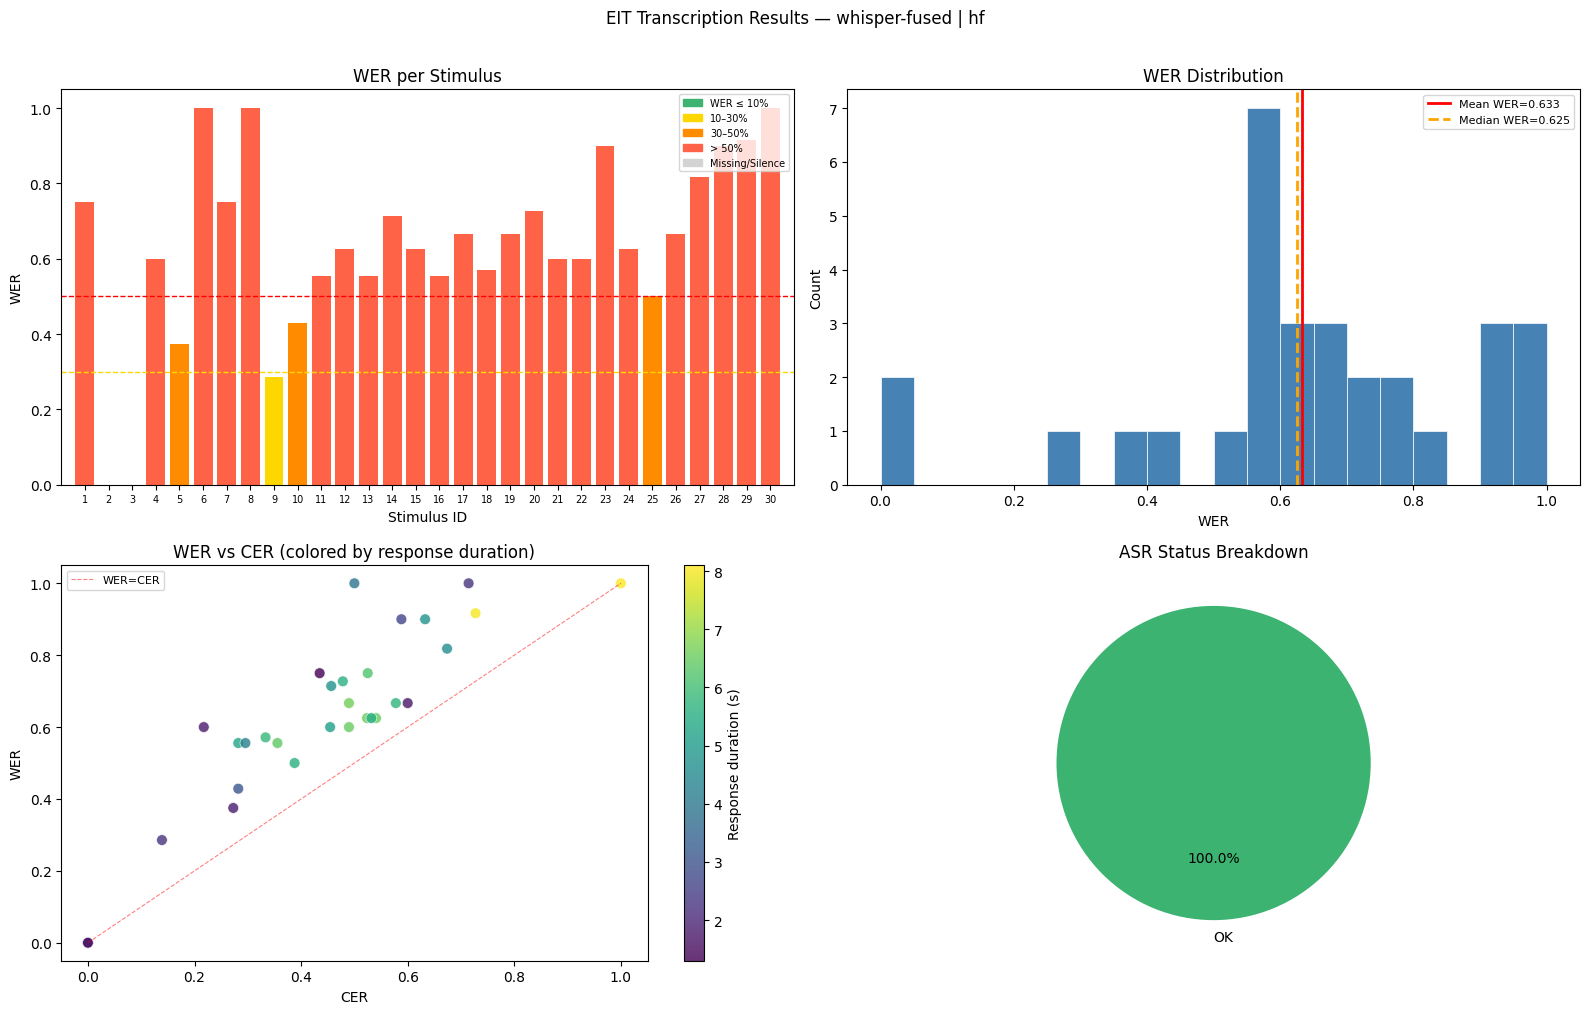

In [16]:
def plot_wer_overview(df, output_path=None):
    """Four-panel summary plot for transcription results."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    scored = df[df['asr_status'] == 'OK'].dropna(subset=['wer', 'cer'])

    # ── 1: WER per stimulus (bar chart) ────────────────────────────────
    ax = axes[0, 0]
    all_ids = range(1, 31)
    wer_by_id = {int(r['stimulus_id']): r['wer']
                  for _, r in df.iterrows() if pd.notna(r.get('wer'))}
    bar_vals   = [wer_by_id.get(i, None) for i in all_ids]
    bar_colors = []
    for v in bar_vals:
        if v is None:      bar_colors.append('lightgray')
        elif v <= 0.1:     bar_colors.append('mediumseagreen')
        elif v <= 0.3:     bar_colors.append('gold')
        elif v <= 0.5:     bar_colors.append('darkorange')
        else:              bar_colors.append('tomato')

    ax.bar(list(all_ids),
           [v if v is not None else 0 for v in bar_vals],
           color=bar_colors, edgecolor='none', width=0.8)
    ax.axhline(0.5, color='red',  ls='--', lw=1, label='WER=50%')
    ax.axhline(0.3, color='gold', ls='--', lw=1, label='WER=30%')
    ax.set(xlabel='Stimulus ID', ylabel='WER', title='WER per Stimulus',
           xlim=(0, 31), ylim=(0, 1.05))
    ax.set_xticks(range(1, 31))
    ax.tick_params(axis='x', labelsize=7)
    ax.legend(fontsize=8)
    # Color legend
    legend_patches = [
        mpatches.Patch(color='mediumseagreen', label='WER ≤ 10%'),
        mpatches.Patch(color='gold',           label='10–30%'),
        mpatches.Patch(color='darkorange',     label='30–50%'),
        mpatches.Patch(color='tomato',         label='> 50%'),
        mpatches.Patch(color='lightgray',      label='Missing/Silence'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', fontsize=7)

    # ── 2: WER histogram ─────────────────────────────────────────────
    ax2 = axes[0, 1]
    if len(scored):
        ax2.hist(scored['wer'], bins=20, color='steelblue',
                 edgecolor='white', linewidth=0.5)
        ax2.axvline(scored['wer'].mean(), color='red', lw=2,
                    label=f"Mean WER={scored['wer'].mean():.3f}")
        ax2.axvline(scored['wer'].median(), color='orange', lw=2, ls='--',
                    label=f"Median WER={scored['wer'].median():.3f}")
        ax2.set(xlabel='WER', ylabel='Count', title='WER Distribution')
        ax2.legend(fontsize=8)

    # ── 3: WER vs CER scatter ─────────────────────────────────────────
    ax3 = axes[1, 0]
    if len(scored):
        sc = ax3.scatter(scored['cer'], scored['wer'],
                          c=scored['response_duration'],
                          cmap='viridis', s=60, alpha=0.8, edgecolors='white', lw=0.5)
        plt.colorbar(sc, ax=ax3, label='Response duration (s)')
        ax3.plot([0, 1], [0, 1], 'r--', lw=0.8, alpha=0.5, label='WER=CER')
        ax3.set(xlabel='CER', ylabel='WER', title='WER vs CER (colored by response duration)',
                xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
        ax3.legend(fontsize=8)

    # ── 4: ASR status breakdown ────────────────────────────────────────
    ax4 = axes[1, 1]
    status_counts = df['asr_status'].value_counts()
    status_colors = {'OK': 'mediumseagreen', 'MISSING': 'lightgray',
                     'SILENCE': 'steelblue', 'EMPTY': 'tomato'}
    colors = [status_colors.get(s, 'gray') for s in status_counts.index]
    ax4.pie(status_counts.values, labels=status_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax4.set_title('ASR Status Breakdown')

    plt.suptitle(f'EIT Transcription Results — whisper-{MODEL_SIZE} | {ACTIVE_BACKEND}',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_wer_overview(transcription_df,
                   output_path=OUTPUT_DIR / '01_wer_overview.png')

Saved: eit_output_v3/038012_2A_preprocessed/transcriptions/02_transcription_detail.png


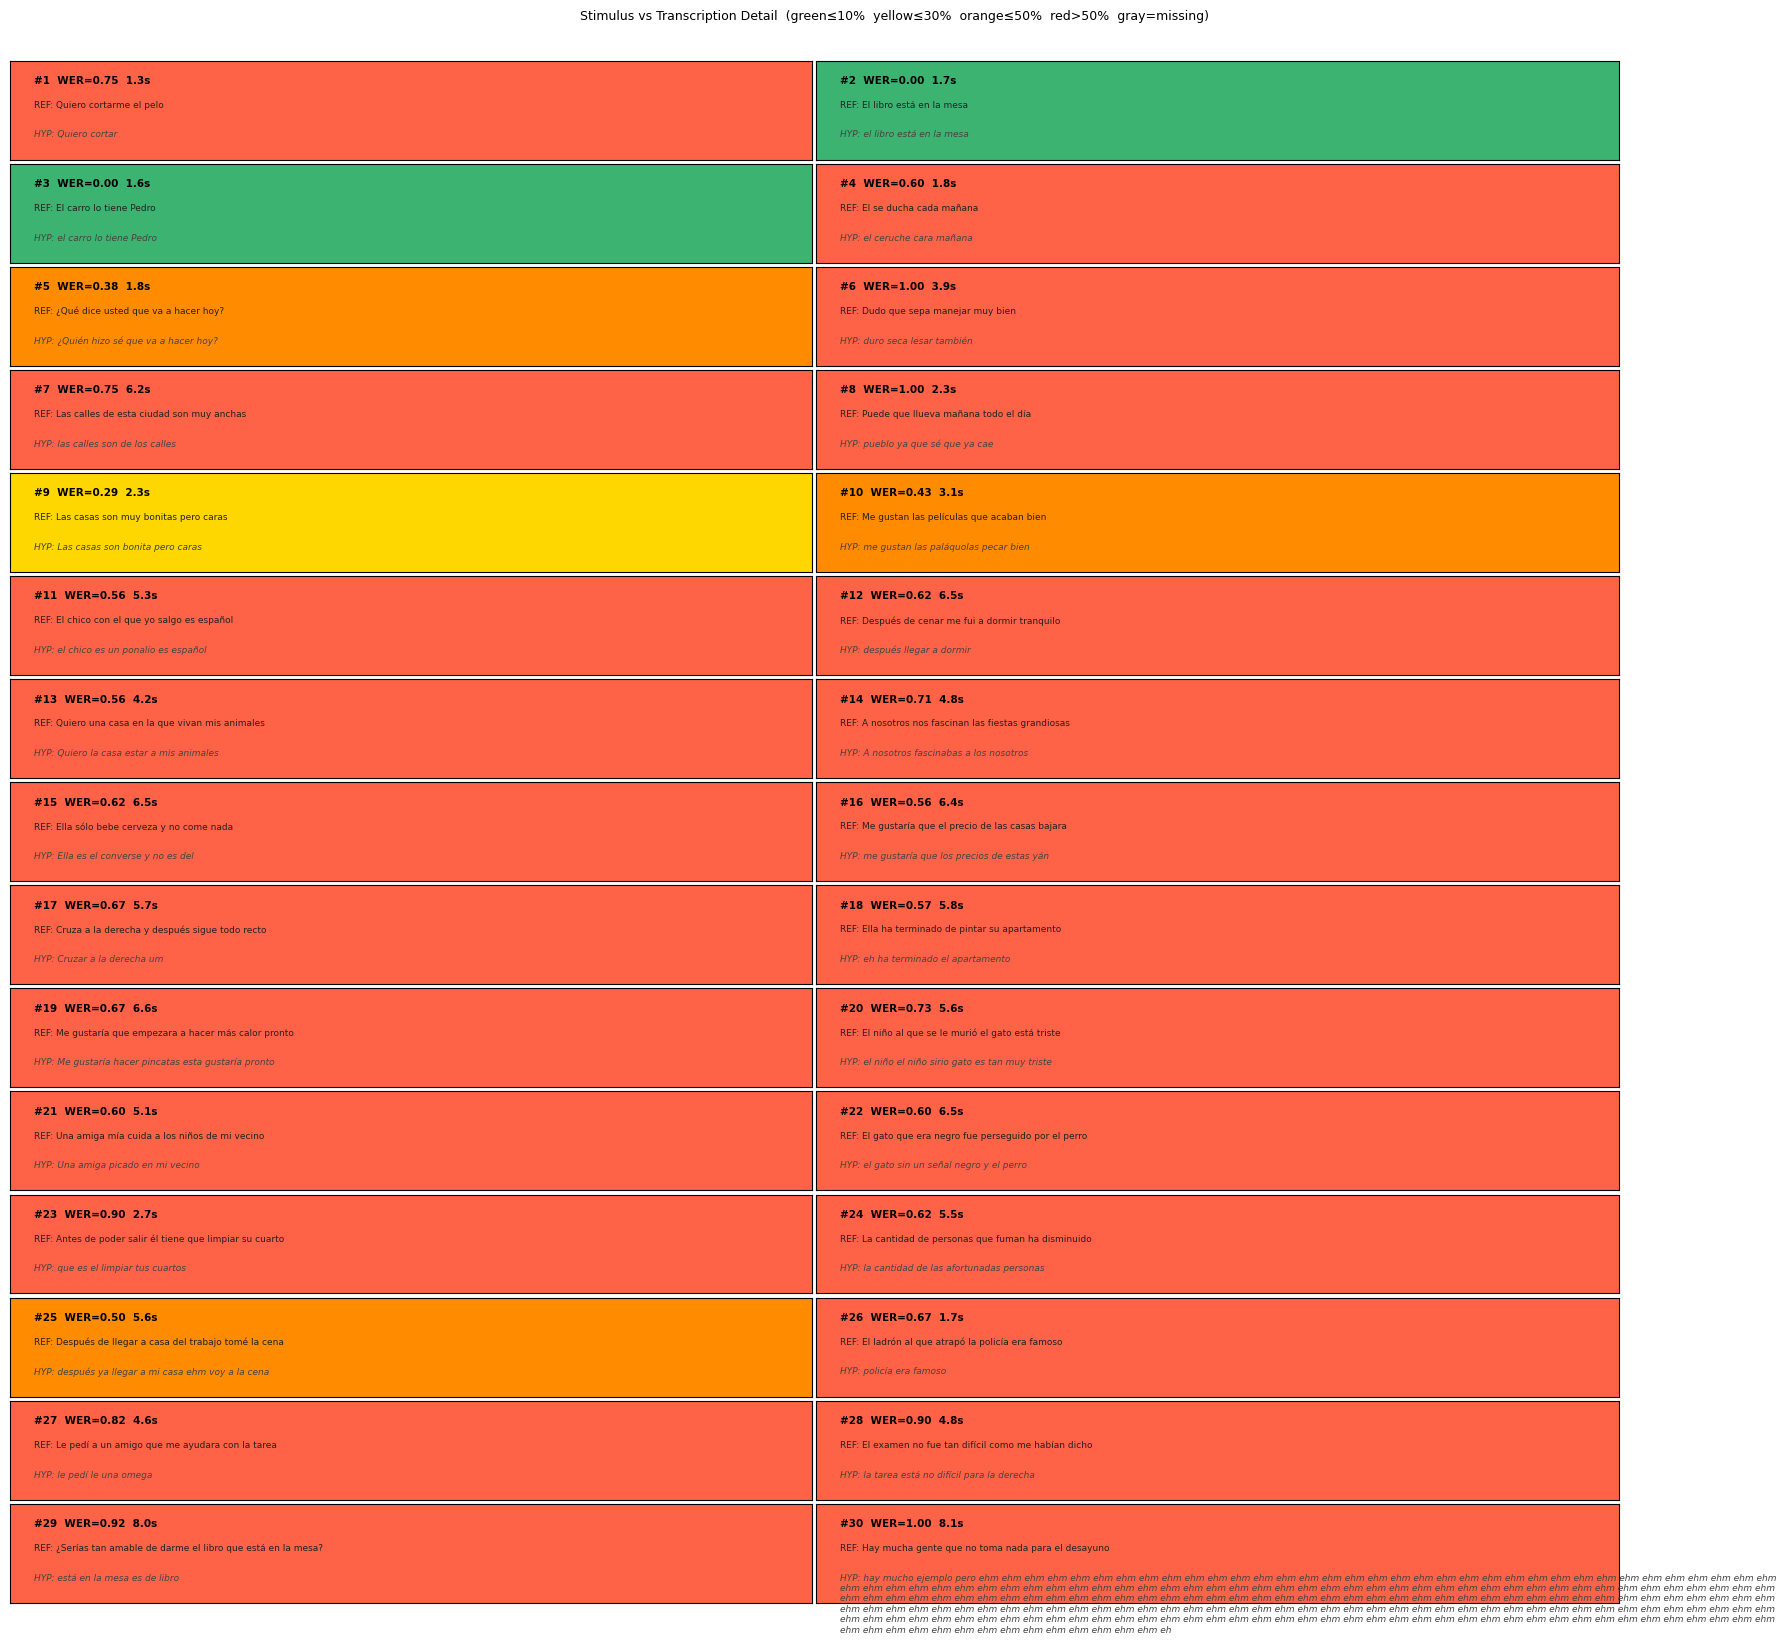

In [17]:
def plot_transcription_detail(df, output_path=None):
    """Side-by-side stimulus vs transcription for all 30 slots."""
    n_cols = 2
    n_rows = 15  # 30 pairs / 2 columns
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(18, n_rows * 1.1))
    axes_flat = axes.flatten()

    wer_colors = lambda w: (
        'mediumseagreen' if w is not None and w <= 0.1 else
        'gold'           if w is not None and w <= 0.3 else
        'darkorange'     if w is not None and w <= 0.5 else
        'tomato'         if w is not None else
        'lightgray'
    )

    for idx, row in df.iterrows():
        ax    = axes_flat[idx]
        sid   = int(row['stimulus_id'])
        wer   = row.get('wer')
        color = wer_colors(wer)

        # Colored background
        ax.set_facecolor(color)
        ax.set_alpha(0.15)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])

        wer_str  = f"WER={wer:.2f}" if wer is not None else row['asr_status']
        dur_str  = f"{row['response_duration']:.1f}s" if pd.notna(row.get('response_duration')) else ''
        ref_text = row['stimulus_text']
        hyp_text = row.get('transcription', '') or '[no transcription]'

        ax.text(0.03, 0.85, f"#{sid}  {wer_str}  {dur_str}",
                transform=ax.transAxes, fontsize=7.5, fontweight='bold', va='top')
        ax.text(0.03, 0.60, f"REF: {ref_text}",
                transform=ax.transAxes, fontsize=6.5, va='top', color='#222',
                wrap=True)
        ax.text(0.03, 0.30, f"HYP: {hyp_text}",
                transform=ax.transAxes, fontsize=6.5, va='top', color='#444',
                style='italic', wrap=True)

    # Hide unused
    for j in range(len(df), len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle('Stimulus vs Transcription Detail  '
                 '(green≤10%  yellow≤30%  orange≤50%  red>50%  gray=missing)',
                 fontsize=9, y=1.005)
    plt.tight_layout(h_pad=0.3, w_pad=0.3)
    if output_path:
        plt.savefig(output_path, dpi=130, bbox_inches='tight')
        print(f"Saved: {output_path}")
    plt.show()


plot_transcription_detail(transcription_df,
                           output_path=OUTPUT_DIR / '02_transcription_detail.png')

---
## Section 12 — Export Results

In [18]:
# ── CSV export ────────────────────────────────────────────────────────────
csv_cols = [
    'stimulus_id', 'stimulus_text', 'stimulus_norm',
    'transcription', 'transcription_norm',
    'wer', 'cer', 'n_ref_words', 'n_hyp_words',
    'response_start', 'response_end', 'response_duration',
    'no_speech_prob', 'asr_status', 'backend', 'elapsed_s', 'response_file'
]

csv_path = OUTPUT_DIR / 'transcriptions.csv'
transcription_df[csv_cols].to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"CSV saved: {csv_path}")


# ── XLSX export with color-coded WER ─────────────────────────────────────
try:
    from openpyxl import Workbook
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    def wer_to_hex(wer):
        if wer is None or (isinstance(wer, float) and np.isnan(wer)):
            return 'D3D3D3'  # gray
        if wer <= 0.10: return '90EE90'  # light green
        if wer <= 0.30: return 'FFD700'  # gold
        if wer <= 0.50: return 'FFA500'  # orange
        return 'FF6961'                   # red

    wb  = Workbook()
    ws  = wb.active
    ws.title = 'Transcriptions'

    export_cols = ['stimulus_id','stimulus_text','transcription',
                   'wer','cer','n_ref_words','n_hyp_words',
                   'response_duration','asr_status']

    # Header row
    header_fill = PatternFill(fill_type='solid', fgColor='1F4E79')
    header_font = Font(bold=True, color='FFFFFF')
    for col_idx, col_name in enumerate(export_cols, 1):
        cell = ws.cell(row=1, column=col_idx, value=col_name.upper().replace('_',' '))
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')

    # Data rows
    thin = Side(style='thin', color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for row_idx, row in transcription_df[export_cols].iterrows():
        fill_color = wer_to_hex(row.get('wer'))
        row_fill   = PatternFill(fill_type='solid', fgColor=fill_color)

        for col_idx, val in enumerate(row, 1):
            cell = ws.cell(row=row_idx + 2, column=col_idx, value=val)
            cell.border = border
            cell.alignment = Alignment(wrap_text=True, vertical='top')
            # Color WER and CER columns
            if export_cols[col_idx - 1] in ('wer', 'cer'):
                cell.fill = row_fill
                if isinstance(val, float):
                    cell.number_format = '0.0%'

    # Column widths
    col_widths = [6, 45, 45, 8, 8, 8, 8, 10, 12]
    for i, w in enumerate(col_widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    # Freeze header
    ws.freeze_panes = 'A3'

    # Summary sheet
    ws2 = wb.create_sheet('Summary')
    ok_scored = transcription_df[transcription_df['asr_status']=='OK'].dropna(subset=['wer'])
    summary_data = [
        ('Recording',    Path(SEGMENTS_CSV).parent.name),
        ('Model',        f'whisper-{MODEL_SIZE}'),
        ('Backend',      ACTIVE_BACKEND),
        ('Language',     LANGUAGE),
        ('Total stimuli', len(transcription_df)),
        ('Transcribed',  len(ok_scored)),
        ('Missing',      (transcription_df['asr_status']=='MISSING').sum()),
        ('Silence',      (transcription_df['asr_status']=='SILENCE').sum()),
        ('Mean WER',     f"{ok_scored['wer'].mean()*100:.1f}%" if len(ok_scored) else 'N/A'),
        ('Median WER',   f"{ok_scored['wer'].median()*100:.1f}%" if len(ok_scored) else 'N/A'),
        ('Mean CER',     f"{ok_scored['cer'].mean()*100:.1f}%" if len(ok_scored) else 'N/A'),
    ]
    for r, (k, v) in enumerate(summary_data, 1):
        ws2.cell(row=r, column=1, value=k).font = Font(bold=True)
        ws2.cell(row=r, column=2, value=str(v))
    ws2.column_dimensions['A'].width = 20
    ws2.column_dimensions['B'].width = 25

    xlsx_path = OUTPUT_DIR / 'transcriptions.xlsx'
    wb.save(str(xlsx_path))
    print(f"XLSX saved: {xlsx_path}")

except Exception as e:
    print(f"XLSX export skipped: {e}")


# ── Word timestamps JSON ──────────────────────────────────────────────────
if WORD_TIMESTAMPS:
    word_ts_records = []
    for _, row in transcription_df.iterrows():
        try:
            words = json.loads(row.get('word_timestamps', '[]') or '[]')
            for w in words:
                w['stimulus_id'] = int(row['stimulus_id'])
                word_ts_records.append(w)
        except Exception:
            pass

    if word_ts_records:
        word_ts_df = pd.DataFrame(word_ts_records)
        word_ts_path = OUTPUT_DIR / 'word_timestamps.csv'
        word_ts_df.to_csv(word_ts_path, index=False, encoding='utf-8-sig')
        print(f"Word timestamps: {word_ts_path}")

print(f"\nAll exports saved to: {OUTPUT_DIR}")

CSV saved: eit_output_v3/038012_2A_preprocessed/transcriptions/transcriptions.csv
XLSX saved: eit_output_v3/038012_2A_preprocessed/transcriptions/transcriptions.xlsx

All exports saved to: eit_output_v3/038012_2A_preprocessed/transcriptions


---
## Section 13 — Diagnostic Report

In [19]:
ok_df      = transcription_df[transcription_df['asr_status'] == 'OK']
scored_df  = ok_df.dropna(subset=['wer'])

print("═" * 65)
print("  EIT TRANSCRIPTION PIPELINE — FINAL REPORT")
print("═" * 65)
print(f"  Recording      : {Path(SEGMENTS_CSV).parent.name}")
print(f"  Model          : whisper-{MODEL_SIZE}")
print(f"  Backend        : {ACTIVE_BACKEND} ({CHIP})")
print(f"  Language       : {LANGUAGE}")
print()
print(f"  Total stimuli  : {len(transcription_df)}")
print(f"  Transcribed    : {len(ok_df)}")
print(f"  Missing (seg.) : {(transcription_df['asr_status']=='MISSING').sum()}")
print(f"  Silence        : {(transcription_df['asr_status']=='SILENCE').sum()}")
print()
if len(scored_df):
    print(f"  Mean WER       : {scored_df['wer'].mean()*100:.2f}%")
    print(f"  Median WER     : {scored_df['wer'].median()*100:.2f}%")
    print(f"  Mean CER       : {scored_df['cer'].mean()*100:.2f}%")
    print()
    # Best and worst responses
    best  = scored_df.loc[scored_df['wer'].idxmin()]
    worst = scored_df.loc[scored_df['wer'].idxmax()]
    print(f"  Best response  (#{ int(best['stimulus_id'])} WER={best['wer']:.3f}):")
    print(f"    REF: {best['stimulus_text']}")
    print(f"    HYP: {best['transcription']}")
    print()
    print(f"  Worst response (#{ int(worst['stimulus_id'])} WER={worst['wer']:.3f}):")
    print(f"    REF: {worst['stimulus_text']}")
    print(f"    HYP: {worst['transcription']}")
print()
print(f"  Outputs        : {OUTPUT_DIR}")
print("═" * 65)

# Full results table
display(transcription_df[['stimulus_id','stimulus_text','transcription',
                            'wer','cer','asr_status']].to_string(index=False))

═════════════════════════════════════════════════════════════════
  EIT TRANSCRIPTION PIPELINE — FINAL REPORT
═════════════════════════════════════════════════════════════════
  Recording      : 038012_2A_preprocessed
  Model          : whisper-fused
  Backend        : hf (apple_silicon)
  Language       : es

  Total stimuli  : 30
  Transcribed    : 30
  Missing (seg.) : 0
  Silence        : 0

  Mean WER       : 63.26%
  Median WER     : 62.50%
  Mean CER       : 45.02%

  Best response  (#2 WER=0.000):
    REF: El libro está en la mesa
    HYP: el libro está en la mesa

  Worst response (#6 WER=1.000):
    REF: Dudo que sepa manejar muy bien
    HYP: duro seca lesar también

  Outputs        : eit_output_v3/038012_2A_preprocessed/transcriptions
═════════════════════════════════════════════════════════════════


' stimulus_id                                             stimulus_text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 transcription    wer    cer asr_status\n           1            

---
## Section 14 — Batch Mode: All 4 Recordings

In [20]:
# List of segments CSVs from all recordings
SEGMENTS_CSV_LIST = [
    "eit_output_v3/038015_1A_preprocessed/segments.csv",
    "eit_output_v3/038012_2A_preprocessed/segments.csv",
    "eit_output_v3/038011_1A_preprocessed/segments.csv",
    "eit_output_v3/038010_2A_preprocessed/segments.csv",
]

all_results = []

for csv_path in SEGMENTS_CSV_LIST:
    if not os.path.exists(csv_path):
        print(f"SKIP (not found): {csv_path}")
        continue

    print(f"\n{'='*55}")
    print(f"Processing: {Path(csv_path).parent.name}")
    print(f"{'='*55}")

    try:
        segs_df  = load_segments(csv_path)
        to_trans = segs_df[segs_df['status']=='OK'].copy().reset_index(drop=True)
        miss_seg = segs_df[segs_df['status']=='MISSING'].copy()

        out_dir  = Path(csv_path).parent / 'transcriptions'
        out_dir.mkdir(parents=True, exist_ok=True)

        ckpt_path = out_dir / 'transcription_checkpoint.json'
        ckpt      = load_checkpoint(ckpt_path)

        trans_df  = run_batch_transcription(
            to_trans, model, ACTIVE_BACKEND, ckpt, ckpt_path, out_dir
        )

        if not miss_seg.empty:
            miss_recs = [_make_missing_record(r) for _, r in miss_seg.iterrows()]
            trans_df  = pd.concat([trans_df, pd.DataFrame(miss_recs)], ignore_index=True)

        trans_df = trans_df.sort_values('stimulus_id').reset_index(drop=True)
        trans_df.to_csv(out_dir / 'transcriptions.csv', index=False, encoding='utf-8-sig')

        # Summary
        scored = trans_df[trans_df['asr_status']=='OK'].dropna(subset=['wer'])
        summary = {
            'recording'   : Path(csv_path).parent.name,
            'transcribed' : len(scored),
            'missing'     : (trans_df['asr_status']=='MISSING').sum(),
            'mean_wer'    : round(scored['wer'].mean(), 4) if len(scored) else None,
            'mean_cer'    : round(scored['cer'].mean(), 4) if len(scored) else None,
        }
        all_results.append(summary)
        print(f"  Done: {summary['transcribed']}/30 transcribed, Mean WER={summary['mean_wer']}")

    except Exception as e:
        print(f"  ERROR: {e}")
        all_results.append({'recording': Path(csv_path).parent.name, 'error': str(e)})

# Batch summary table
if all_results:
    batch_summary = pd.DataFrame(all_results)
    print(f"\n{'='*55}")
    print("BATCH SUMMARY")
    print(f"{'='*55}")
    print(batch_summary.to_string(index=False))

    batch_summary.to_csv(
        Path(SEGMENTS_CSV_LIST[0]).parent.parent / 'batch_transcription_summary.csv',
        index=False
    )


Processing: 038015_1A_preprocessed
Loaded: eit_output_v3/038015_1A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0


Transcribing: 100%|██████████| 30/30 [12:07<00:00, 24.23s/it]



Total transcription time: 726.6s (24.22s/seg avg)  [stimulus-prompted]
  Done: 30/30 transcribed, Mean WER=0.2493

Processing: 038012_2A_preprocessed
Loaded: eit_output_v3/038012_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0
Checkpoint loaded: 30 previously completed segments.


Transcribing: 100%|██████████| 30/30 [00:00<00:00, 33644.15it/s]



Total transcription time: 0.0s (0.00s/seg avg)  [stimulus-prompted]
  Done: 30/30 transcribed, Mean WER=0.6326

Processing: 038011_1A_preprocessed
Loaded: eit_output_v3/038011_1A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0


Transcribing: 100%|██████████| 30/30 [12:11<00:00, 24.37s/it]



Total transcription time: 730.7s (24.36s/seg avg)  [stimulus-prompted]
  Done: 30/30 transcribed, Mean WER=0.3833

Processing: 038010_2A_preprocessed
Loaded: eit_output_v3/038010_2A_preprocessed/segments.csv
  Total rows     : 30
  Responses OK   : 30
  Missing        : 0


Transcribing: 100%|██████████| 30/30 [12:38<00:00, 25.28s/it]


Total transcription time: 757.9s (25.26s/seg avg)  [stimulus-prompted]
  Done: 30/30 transcribed, Mean WER=0.5182

BATCH SUMMARY
             recording  transcribed  missing  mean_wer  mean_cer
038015_1A_preprocessed           30        0    0.2493    0.1552
038012_2A_preprocessed           30        0    0.6326    0.4502
038011_1A_preprocessed           30        0    0.3833    0.2596
038010_2A_preprocessed           30        0    0.5182    0.3842


---
## Appendix — Calibration & Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| High WER on all segments | Wrong language / no language forced | Confirm `LANGUAGE='es'`, lower `TEMPERATURE` |
| Many SILENCE flags | `NO_SPEECH_THRESH` too low | Raise to `0.7` or `0.8` |
| Missing initial/final words | Insufficient padding | Raise `AUDIO_PAD_S` to `0.3` |
| Slow transcription | Using OpenAI backend on Intel | Install `pywhispercpp`; on M-chip install `mlx-whisper` |
| MLX model download fails | No internet / wrong model ID | Check `MLX_MODEL_MAP`, use `openai` fallback |
| Transcription includes previous segment | `CONDITION_ON_PREV=True` | Keep `False` for independent clips |
| Hallucinated text on silence | Whisper hallucinates on short silence | Raise `NO_SPEECH_THRESH` to `0.7` |

### Quick Re-run Cell (adjust parameters without reloading model)

In [21]:
# # ── Retranscribe single segment to test parameters ──────────────────────
# STIMULUS_ID_TO_TEST = 1       # Change to any stimulus ID
# TEST_TEMPERATURE    = 0.0
# TEST_BEAM_SIZE      = 5

# test_row = segments_df[segments_df['stimulus_id'] == STIMULUS_ID_TO_TEST].iloc[0]
# test_file = str(test_row['response_file'])

# if os.path.exists(test_file):
#     result = transcribe(
#         test_file, model, ACTIVE_BACKEND,
#         temperature=TEST_TEMPERATURE,
#         beam_size=TEST_BEAM_SIZE
#     )
#     scores = score_transcription(result['text'], test_row['stimulus_text'])

#     print(f"Stimulus #{STIMULUS_ID_TO_TEST}")
#     print(f"  REF : {test_row['stimulus_text']}")
#     print(f"  HYP : {result['text']}")
#     print(f"  WER : {scores['wer']:.4f}")
#     print(f"  CER : {scores['cer']:.4f}")
#     print(f"  Time: {result['elapsed_s']:.2f}s")
#     if result.get('words'):
#         print(f"  Words: {result['words']}")
# else:
#     print(f"File not found: {test_file}")